# MVP Análise de Dados e Boas Práticas

**Nome:** Giulia Barros dos Reis

**Matrícula:** 4052025001231

**Dataset:** [Online Payments Fraud Detection Dataset
](https://raw.githubusercontent.com/codedbygiulia/mvp-fraude-pagamentos/main/fraud_dataset_sample_50000.csv)



# Descrição do Problema


O crescimento dos pagamentos digitais trouxe maior praticidade para consumidores, empresas e instituições financeiras. No entanto, com o crescimento acelerado dos meios de pagamento móvel e digital, a detecção automatizada de comportamentos fraudulentos tornou-se essencial para proteger consumidores e empresas de prejuízos bilionários, tornando a identificação de operações suspeitas um desafio relevante para a área de dados.

Neste trabalho, será analisado um conjunto de dados de transações financeiras com o objetivo de compreender padrões associados à ocorrência de fraude em pagamentos. O foco do MVP não é desenvolver uma solução final de classificação, mas sim realizar uma análise exploratória consistente e aplicar etapas importantes de pré-processamento dos dados, preparando o conjunto para futuras abordagens de modelagem.

O dataset utilizado neste trabalho é uma amostra do **PaySim**, um simulador de transações financeiras móveis desenvolvido com base em dados reais de uma empresa de serviços financeiros africana. Ele simula **30 dias de transações** e foi originalmente publicado no Kaggle por Lopez-Rojas et al. A amostra utilizada contém **50.000 transações** extraídas do conjunto original, mantendo a proporção natural de transações fraudulentas.

A partir desse problema, busca-se investigar como atributos como tipo de transação, valor movimentado e saldos das contas antes e depois da operação podem estar relacionados à identificação de transações fraudulentas. Além disso, pretende-se avaliar a qualidade dos dados, identificar possíveis inconsistências e aplicar transformações que tornem o dataset mais adequado para análise.

## Hipóteses do Problema

Com base no contexto do problema e nos atributos presentes no dataset, as hipóteses que tracei são as seguintes:

As hipóteses foram formuladas **antes da análise dos dados**, com base em conhecimento de domínio sobre fraudes financeiras. Formulá-las previamente é uma prática essencial: garante que a análise seja orientada por perguntas concretas em vez de exploração aleatória, e permite que os achados sejam avaliados de forma objetiva ao final do trabalho.

1. **Transações do tipo TRANSFER e CASH_OUT concentram a maior parte das fraudes**, pois são os meios mais comuns de movimentação ilícita de recursos — seja pela facilidade de transferir fundos para outra conta ou de sacar em dinheiro.
2. **Transações fraudulentas tendem a zerar o saldo de origem**, ou seja, a conta de origem é esvaziada completamente, pois o objetivo do fraudador é extrair o máximo de recursos disponíveis.
3. **Os valores envolvidos em fraudes são, em média, mais altos do que os de transações legítimas**, sugerindo que fraudadores selecionam intencionalmente contas com saldo elevado para maximizar o retorno da operação ilícita.
4. **O saldo do destinatário costuma ser zero antes da fraude**, indicando que contas de destino são criadas especificamente para receber recursos fraudulentos — as chamadas "contas mula".

## Tipo de Problema

O problema pode ser caracterizado como um problema de aprendizado supervisionado de classificação binária, pois o dataset possui uma variável alvo `isFraud` que indica se uma transação é fraudulenta (1) ou legítima (0). Entretanto, embora o problema tenha natureza supervisionada, o foco deste trabalho está concentrado nas etapas de definição do problema, análise exploratória e pré-processamento dos dados. Dessa forma, a construção de um modelo preditivo completo não constitui o objetivo principal deste MVP, embora os dados sejam preparados para possibilitar uma etapa futura de modelagem.

## Seleção de Dados

Para este trabalho, foi selecionado um dataset relacionado a transações financeiras e fraude em pagamentos digitais. A escolha foi motivada pela relevância prática do problema, pela presença de atributos interpretáveis e pela possibilidade de aplicar diferentes técnicas de análise exploratória e pré-processamento de dados.

O conjunto original apresenta volume elevado de registros, o que dificulta o armazenamento em repositórios públicos e aumenta o tempo de execução do notebook no Google Colab. Por esse motivo, foi utilizada uma versão amostrada do dataset (50.000 transações do conjunto PaySim completo, que contém mais de 6 milhões de transações). Para preservar a qualidade da análise, foram mantidos os registros de fraude, e os registros não fraudulentos foram amostrados até compor um subconjunto de 50.000 instâncias.

Essa estratégia permitiu viabilizar a execução do trabalho de forma mais eficiente, sem comprometer o objetivo do MVP, que é compreender o problema, explorar os dados e realizar seu pré-processamento.

## Atributos do Dataset

O dataset contém **11 atributos** descritos a seguir:

| Atributo | Tipo | Descrição |
|---|---|---|
| `step` | Numérico (int) | Unidade de tempo da simulação — 1 step = 1 hora. O dataset cobre de 1 a 744 steps (30 dias) |
| `type` | Categórico | Tipo da transação: CASH_IN, CASH_OUT, DEBIT, PAYMENT ou TRANSFER |
| `amount` | Numérico (float) | Valor da transação em moeda local |
| `nameOrig` | Categórico | Identificador único do cliente de origem da transação |
| `oldbalanceOrg` | Numérico (float) | Saldo da conta de origem **antes** da transação |
| `newbalanceOrig` | Numérico (float) | Saldo da conta de origem **após** a transação |
| `nameDest` | Categórico | Identificador único do cliente de destino da transação |
| `oldbalanceDest` | Numérico (float) | Saldo da conta de destino **antes** da transação |
| `newbalanceDest` | Numérico (float) | Saldo da conta de destino **após** a transação |
| `isFraud` | Binário (int) | **Variável-alvo**: 1 se a transação é fraudulenta, 0 caso contrário |
| `isFlaggedFraud` | Binário (int) | Flag do sistema de regras: 1 se o sistema sinalizou automaticamente como suspeita (transf. > 200.000) |

**Observações importantes:** `nameOrig` e `nameDest` são identificadores únicos de alta cardinalidade e serão removidos no pré-processamento. `isFlaggedFraud` é gerado pelo próprio sistema financeiro e sua inclusão como feature causaria *data leakage*, sendo também removida.

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção reúne as bibliotecas necessárias para a análise exploratória, visualização e pré-processamento dos dados do problema de fraude em pagamentos digitais. Além disso, é realizado o carregamento do dataset a partir de um arquivo CSV hospedado em um repositório público no GitHub, conforme solicitado no enunciado do trabalho. Após a leitura, os dados são armazenados em um DataFrame do pandas, estrutura que será utilizada nas etapas seguintes de inspeção, análise e transformação dos dados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# configurações globais de visualização
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', '{:.4f}'.format)

# seed global — garante os mesmos resultados em qualquer execução
RANDOM_STATE = 42

In [ ]:
# carregamento do dataset (aqui, ele fica disponível nesse método)
url = "https://raw.githubusercontent.com/codedbygiulia/mvp-fraude-pagamentos/main/fraud_dataset_sample_50000.csv"

df = pd.read_csv(url)

print(f'Dataset carregado com sucesso!')
print(f'Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas')

Dataset carregado com sucesso!
Shape: 50,000 linhas x 11 colunas


O dataset foi carregado com sucesso com 50.000 linhas e 11 colunas, conforme esperado. O próximo passo é inspecionar visualmente as primeiras e últimas linhas para identificar possíveis inconsistências de formatação, valores claramente absurdos ou padrões inesperados antes de qualquer análise estatística.

In [ ]:
# primeiras linhas

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,46,CASH_IN,82812.6100,C2045765496,94057.9900,176870.6000,C1616574477,591196.0000,508383.3800,0,0
1,266,PAYMENT,3123.2400,C1551703422,50036.0000,46912.7600,M616455084,0.0000,0.0000,0,0
2,17,TRANSFER,305627.0000,C1711670940,305627.0000,0.0000,C385061535,0.0000,0.0000,1,0
3,137,PAYMENT,51680.7000,C151179513,243532.8000,191852.1000,M1730703519,0.0000,0.0000,0,0
4,359,CASH_IN,30096.9900,C1061023977,7599823.5000,7629920.5000,C1246610976,106350.5900,76253.6000,0,0


A inspeção das primeiras linhas revela que o dataset possui estrutura bem definida, sem colunas mal nomeadas ou formatadas incorretamente. Os identificadores `nameOrig` e `nameDest` seguem padrão alfanumérico (ex: C1234567890), confirmando que são IDs e não atributos analíticos. Os valores de `amount` e saldos variam amplamente em escala, o que antecipa a necessidade de transformações. Já nas primeiras linhas aparecem transações com `newbalanceOrig = 0`, sugerindo que o esvaziamento de conta é recorrente. As colunas `isFraud` e `isFlaggedFraud` são binárias (0 ou 1), como esperado.

In [ ]:
df.tail(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
49990,43,TRANSFER,302290.7500,C696216227,31185.8200,0.0000,C77244151,615100.5600,917391.3000,0,0
49991,188,PAYMENT,598.0700,C1917853437,10464.0000,9865.9300,M594065888,0.0000,0.0000,0,0
49992,395,PAYMENT,12109.7300,C1152740924,283556.9700,271447.2200,M101087992,0.0000,0.0000,0,0
49993,204,CASH_OUT,158590.2800,C1924580519,0.0000,0.0000,C613582737,1292661.9000,1451252.1000,0,0
49994,567,TRANSFER,122816.6700,C1014449898,122816.6700,0.0000,C1843501227,0.0000,0.0000,1,0
49995,382,CASH_OUT,542461.7500,C664480557,0.0000,0.0000,C1725191429,1757516.2000,2299978.0000,0,0
49996,251,PAYMENT,16441.7800,C466091503,81962.0000,65520.2200,M1997455277,0.0000,0.0000,0,0
49997,353,CASH_OUT,54671.5400,C386772449,0.0000,0.0000,C573931881,7006822.0000,7061493.5000,0,0
49998,71,TRANSFER,1871553.8000,C677678546,1871553.8000,0.0000,C646623849,0.0000,0.0000,1,0
49999,335,CASH_IN,98932.3800,C2033626434,1609496.5000,1708428.9000,C1360574838,3484293.5000,3385361.2000,0,0


Isso é excelente para conferir se o carregamento do arquivo foi feito até o final ou se existem valores nulos acumulados no encerramento da base de dados. As últimas linhas confirmam que os dados não apresentam ordenação temporal sequencial — diferentes valores de `step` aparecem intercalados, o que era esperado para uma amostra aleatória. Não há truncamentos, linhas corrompidas ou valores absurdos ao final. A estrutura das colunas permanece consistente, indicando boa integridade do arquivo.

In [ ]:
# Para mostrar dimensão e colunas.

print("Dimensões do dataset:", df.shape)
print("\nNomes das colunas:")
print(df.columns.tolist())

Dimensões do dataset: (50000, 11)

Nomes das colunas:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


## Análise de Dados

Com o dataset carregado e inspecionado visualmente, iniciamos a **Análise de Dados Exploratória (EDA)**. Esta etapa tem como objetivo compreender profundamente a estrutura, distribuição e relacionamento entre as variáveis, antes de qualquer transformação ou modelagem. A EDA é o alicerce de todo o projeto: ela revela padrões que orientam as decisões de pré-processamento, valida (ou refuta) as hipóteses levantadas, e garante que o cientista de dados entende os dados com que trabalha antes de aplicar algoritmos.

Seguiremos a seguinte ordem: verificação do volume e tipos de dados → duplicatas → estatísticas descritivas → distribuição da variável-alvo → análise por tipo de transação → distribuições individuais → comparações por classe → correlações → análise de padrões comportamentais das hipóteses.

## Total e Tipo das Instâncias

Inicialmente, é importante verificar a quantidade de instâncias e atributos presentes no dataset, além dos tipos de dados de cada coluna. Essa inspeção inicial ajuda a entender a estrutura da base, identificar quais variáveis são numéricas, categóricas ou identificadoras, e orientar as próximas etapas da análise exploratória.

O volume determina quais técnicas são computacionalmente viáveis, os tipos de dados determinam quais operações são aplicáveis — estatísticas descritivas para numéricos, codificações para categóricos e, também, auxilia a identificar desde cedo colunas irrelevantes para evitar o desperdício de processamento. Foi usado `shape`, `dtypes` e `info()` — três funções complementares que juntas fornecem um panorama completo da estrutura do dataset.

In [ ]:
# total de linhas e colunas — confirma o volume esperado
print(f'Número de instâncias (linhas): {df.shape[0]:,}')
print(f'Número de atributos (colunas): {df.shape[1]}')

Número de instâncias (linhas): 50,000
Número de atributos (colunas): 11


In [ ]:
print("Total de instâncias e atributos:", df.shape)

print("\nInformações gerais do dataset: tipos, contagem não-nula e uso de memória")
df.info()

Total de instâncias e atributos: (50000, 11)

Informações gerais do dataset: tipos, contagem não-nula e uso de memória
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            50000 non-null  int64  
 1   type            50000 non-null  object 
 2   amount          50000 non-null  float64
 3   nameOrig        50000 non-null  object 
 4   oldbalanceOrg   50000 non-null  float64
 5   newbalanceOrig  50000 non-null  float64
 6   nameDest        50000 non-null  object 
 7   oldbalanceDest  50000 non-null  float64
 8   newbalanceDest  50000 non-null  float64
 9   isFraud         50000 non-null  int64  
 10  isFlaggedFraud  50000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 4.2+ MB


In [ ]:
print(f'\nTotal de colunas numéricas:    {df.select_dtypes(include=np.number).shape[1]}')
print(f'Total de colunas categóricas: {df.select_dtypes(include="object").shape[1]}')


Total de colunas numéricas:    8
Total de colunas categóricas: 3


In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,46,CASH_IN,82812.6100,C2045765496,94057.9900,176870.6000,C1616574477,591196.0000,508383.3800,0,0
1,266,PAYMENT,3123.2400,C1551703422,50036.0000,46912.7600,M616455084,0.0000,0.0000,0,0
2,17,TRANSFER,305627.0000,C1711670940,305627.0000,0.0000,C385061535,0.0000,0.0000,1,0
3,137,PAYMENT,51680.7000,C151179513,243532.8000,191852.1000,M1730703519,0.0000,0.0000,0,0
4,359,CASH_IN,30096.9900,C1061023977,7599823.5000,7629920.5000,C1246610976,106350.5900,76253.6000,0,0


In [ ]:
print("\nTipos de dados por coluna:")
display(df.dtypes)


Tipos de dados por coluna:


,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


A inspeção inicial mostra que o dataset possui atributos numéricos, categóricos e colunas identificadoras. As variáveis numéricas estão relacionadas principalmente ao valor da transação e aos saldos das contas antes e depois da operação. Já a variável `type` representa uma categoria de transação,  e é a única variável categórica com potencial analítico e exigirá codificação antes da modelagem. Enquanto que `nameOrig` e `nameDest` atuam como identificadores das contas, com alta cardinalidade. A presença da variável `isFraud` confirma que o conjunto de dados permite analisar o problema sob a perspectiva de detecção de fraude em transações financeiras.

Todas as colunas têm 50.000 entradas não-nulas — ausência de valores nulos aparentes, a ser verificada formalmente.

Como o problema envolve a identificação de fraude, é importante observar a distribuição da variável alvo `isFraud`. Essa análise permite verificar a frequência relativa entre transações fraudulentas e não fraudulentas e identificar se existe desbalanceamento entre as classes.

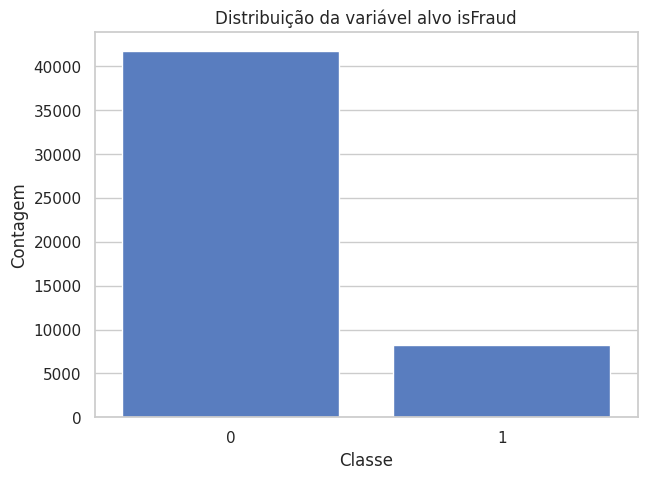

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="isFraud")
plt.title("Distribuição da variável alvo isFraud")
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.show()

In [ ]:
frequencia_absoluta = df["isFraud"].value_counts().sort_index()
frequencia_relativa = (df["isFraud"].value_counts(normalize=True).sort_index() * 100).round(2)

distribuicao_classes = pd.DataFrame({
    "frequencia_absoluta": frequencia_absoluta,
    "frequencia_relativa (%)": frequencia_relativa
})

distribuicao_classes

,frequencia_absoluta,frequencia_relativa (%)
isFraud,,
0,41787,83.5700
1,8213,16.4300


O gráfico de barras mostra como os registros estão distribuídos entre transações fraudulentas e não fraudulentas. Essa visualização é importante porque permite identificar se há desbalanceamento entre as classes, situação comum em problemas de fraude.

Caso a quantidade de fraudes seja significativamente menor, esse aspecto deve ser considerado nas etapas posteriores de preparação dos dados e em uma eventual modelagem futura. O conjunto de dados está desbalanceado. Embora 16% de fraudes seja um número considerável em comparação a cenários reais (onde costuma ser menos de 1%), ainda há muito mais exemplos de transações normais do que fraudulentas. O modelo pode acabar por aprender melhor a identificar o que "não é fraude" do que o que "é fraude" devido a essa disparidade.

## Verificação de Duplicatas


Antes de qualquer análise estatística, o ideal é verificar a presença de linhas duplicadas no dataset. Duplicatas podem distorcer estatísticas descritivas (inflando frequências), enviesar modelos (aumentando artificialmente o peso de certos exemplos) e comprometer a validade da separação treino/teste (a mesma instância poderia aparecer nos dois conjuntos).

 Também considero importante verificar a cardinalidade dos identificadores `nameOrig` e `nameDest` para confirmar que são de fato únicos.

In [ ]:
# verificação de linhas 100% duplicadas
n_duplicatas = df.duplicated().sum()
print(f'Linhas duplicadas encontradas: {n_duplicatas}')

# cardinalidade dos identificadores — confirma se são únicos
print(f'\nValores únicos em nameOrig: {df["nameOrig"].nunique():,}')
print(f'Valores únicos em nameDest: {df["nameDest"].nunique():,}')
print(f'Valores únicos em type:     {df["type"].nunique()} → {df["type"].unique()}')

Linhas duplicadas encontradas: 0

Valores únicos em nameOrig: 50,000
Valores únicos em nameDest: 48,280
Valores únicos em type:     5 → ['CASH_IN' 'PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT']


O dataset não apresenta linhas duplicadas — resultado esperado para um dataset gerado por simulação computacional. A alta cardinalidade de `nameOrig` e `nameDest` (próxima de 50.000) confirma que são identificadores únicos sem valor preditivo direto, justificando sua remoção na etapa de pré-processamento. A coluna `type` possui exatamente 5 categorias distintas — quantidade gerenciável para One-Hot Encoding.

## Estatísticas Descritivas

A análise estatística descritiva permite resumir o comportamento dos atributos numéricos, observando medidas como média, desvio padrão, valores mínimos, máximos e quartis. Essas informações ajudam a identificar dispersão, assimetria e possíveis indícios de outliers. Usamos `describe()` como ponto de partida, complementado pelo Coeficiente de Variação, assimetria e curtose — métricas que caracterizam matematicamente a **forma** das distribuições.
```
# Isto está formatado como código
```



In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,50000.0000,NaN,NaN,NaN,263.9184,163.5394,1.0000,157.0000,254.0000,355.0000,743.0000
type,50000,5,CASH_OUT,18854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,50000.0000,NaN,NaN,NaN,393127.4479,1239935.4299,0.0000,17039.5600,102098.4700,267028.6800,69886730.0000
nameOrig,50000,50000,C1596047986,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,50000.0000,NaN,NaN,NaN,952269.8540,2980457.6261,0.0000,0.0000,25638.0000,252059.5000,59585040.0000
newbalanceOrig,50000.0000,NaN,NaN,NaN,732238.7602,2755142.1601,0.0000,0.0000,0.0000,82263.7400,49585040.0000
nameDest,50000,48280,C1561140816,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,50000.0000,NaN,NaN,NaN,1006242.3433,3433556.8081,0.0000,0.0000,58012.2900,807589.3450,236230510.0000
newbalanceDest,50000.0000,NaN,NaN,NaN,1233634.3757,3781654.8992,0.0000,0.0000,190388.8100,1111801.1000,236726500.0000
isFraud,50000.0000,NaN,NaN,NaN,0.1643,0.3705,0.0000,0.0000,0.0000,0.0000,1.0000


Coluna isFraud: A média é 0.1643. Isso indica que cerca de 16,4% das transações nesta amostra são marcadas como fraude.

Coluna amount: O valor máximo de uma transação é enorme ($69.886.730$), enquanto a média é bem menor ($393.127$). Isso sugere a presença de outliers (valores fora da curva).

Coluna type: O tipo de transação mais comum é CASH_OUT, ocorrendo 18.854 vezes.

Os saldos de origem e destino apresentam desvios padrão superiores às respectivas médias, revelando dispersão extrema. A amplitude de escala é enorme: `oldbalanceOrg` varia de 0 a ~59 milhões, exigindo normalização ou padronização antes de qualquer modelagem.

/tmp/ipykernel_3077/602565064.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=df, palette='viridis')


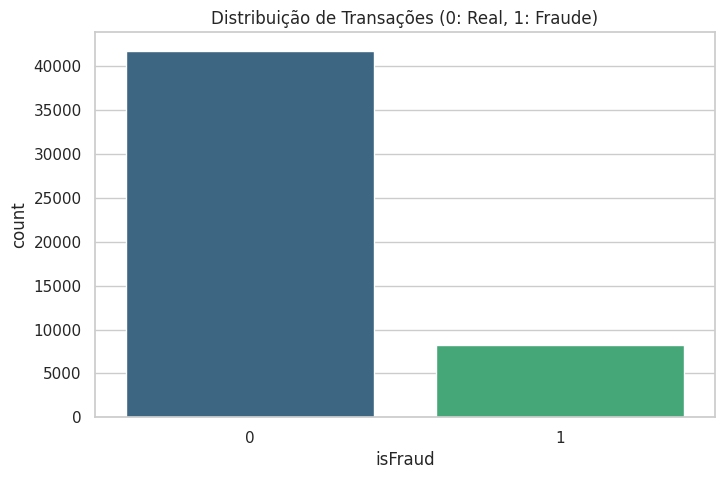

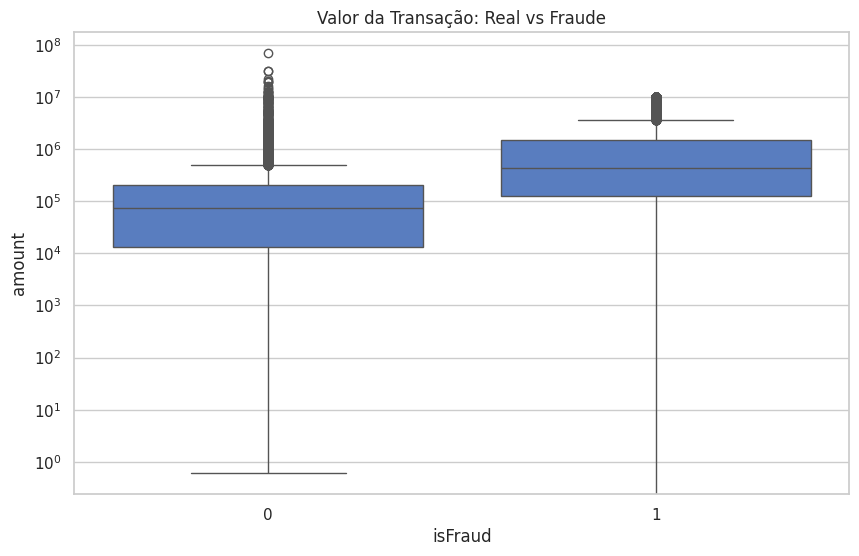

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Verificando a distribuição de fraudes
plt.figure(figsize=(8, 5))
sns.countplot(x='isFraud', data=df, palette='viridis')
plt.title('Distribuição de Transações (0: Real, 1: Fraude)')
plt.show()

# 2. Comparando valores de transação
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log') # Escala logarítmica porque os valores variam muito
plt.title('Valor da Transação: Real vs Fraude')
plt.show()

In [ ]:
# estatísticas descritivas básicas do dataset
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000
mean,263.9184,393127.4479,952269.8540,732238.7602,1006242.3433,1233634.3757,0.1643,0.0003
std,163.5394,1239935.4299,2980457.6261,2755142.1601,3433556.8081,3781654.8992,0.3705,0.0179
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,157.0000,17039.5600,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,254.0000,102098.4700,25638.0000,0.0000,58012.2900,190388.8100,0.0000,0.0000
75%,355.0000,267028.6800,252059.5000,82263.7400,807589.3450,1111801.1000,0.0000,0.0000
max,743.0000,69886730.0000,59585040.0000,49585040.0000,236230510.0000,236726500.0000,1.0000,1.0000


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

Neste contexto, comparar a média com a mediana nos permite quantificar o grau de assimetria de cada variável: quanto maior a diferença entre elas, mais assimétrica é a distribuição.

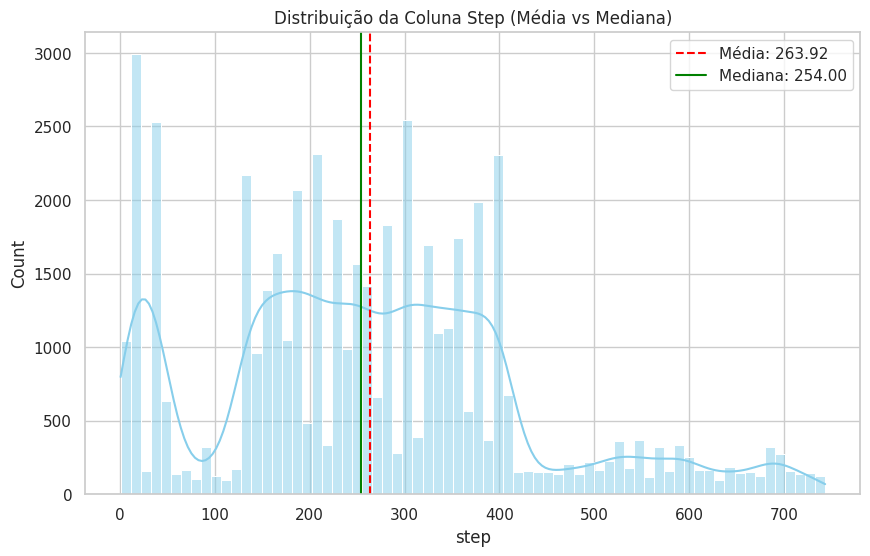

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['step'], kde=True, color='skyblue')

# Adicionando linha da média e da mediana
plt.axvline(df['step'].mean(), color='red', linestyle='--', label=f"Média: {df['step'].mean():.2f}")
plt.axvline(df['step'].median(), color='green', linestyle='-', label=f"Mediana: {df['step'].median():.2f}")

plt.title('Distribuição da Coluna Step (Média vs Mediana)')
plt.legend()
plt.show()

In [ ]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
step,263.9184
amount,393127.4479
oldbalanceOrg,952269.8540
newbalanceOrig,732238.7602
oldbalanceDest,1006242.3433
newbalanceDest,1233634.3757
isFraud,0.1643
isFlaggedFraud,0.0003


Distorção em amount (Valor da Transação): A média de 393.127,45 é significativamente superior à mediana (que costuma ser menor em distribuições financeiras). Isso indica uma assimetria positiva, onde um pequeno número de transações de altíssimo valor puxa a média para cima, não representando necessariamente a transação "comum".

Proporção de Fraudes (isFraud): A média de 0.1643 nesta amostra é um dado crítico. Em termos percentuais, isso indica que 16,43% das transações registradas são fraudulentas. Para um modelo de detecção de fraude, esse valor é alto e sugere que a base de dados está balanceada para estudo ou foca em um cenário de alto risco.

Relação Média vs. Mediana no atributo step: Conforme observado no histograma gerado, a média (263.92) está à direita da mediana (254.00). Essa proximidade indica que, para o tempo da transação (step), a distribuição é mais equilibrada do que nos valores monetários, embora ainda apresente uma leve inclinação para a direita.

Saldos Bancários: Variáveis como oldbalanceOrg apresentam médias próximas a 1 milhão, mas com desvios padrão que superam a própria média. Isso reforça que a média, neste contexto, serve mais para entender a magnitude do volume de dinheiro movimentado do que para descrever o perfil de um cliente individual.

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

Foi calculado também o **Coeficiente de Variação (CV = std/mean × 100)**, que normaliza a dispersão e permite comparar a heterogeneidade entre variáveis de escalas diferentes.

In [ ]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

,std
step,163.5394
amount,1239935.4299
oldbalanceOrg,2980457.6261
newbalanceOrig,2755142.1601
oldbalanceDest,3433556.8081
newbalanceDest,3781654.8992
isFraud,0.3705
isFlaggedFraud,0.0179


In [ ]:
# coeficiente de variação (CV%) — mede dispersão relativa entre variáveis de escalas diferentes
media = df.select_dtypes(include=np.number).mean()
std   = df.select_dtypes(include=np.number).std()
cv    = (std / media * 100).round(2)
print('Coeficiente de Variação (%) — quanto maior, mais heterogêneo o atributo:')
print(cv.sort_values(ascending=False))

Coeficiente de Variação (%) — quanto maior, mais heterogêneo o atributo:
isFlaggedFraud   5589.3300
newbalanceOrig    376.2600
oldbalanceDest    341.2300
amount            315.4000
oldbalanceOrg     312.9800
newbalanceDest    306.5500
isFraud           225.5700
step               61.9700
dtype: float64


Os desvios padrão das variáveis financeiras são extremamente elevados. O Coeficiente de Variação acima de 100% em múltiplas colunas indica dispersão extrema — não existe um perfil de transação ou de saldo 'típico' neste dataset. Essa heterogeneidade torna algoritmos baseados em distância (como KNN) especialmente sensíveis à escala das variáveis, tornando a normalização ou padronização indispensável antes de qualquer modelagem.

In [ ]:
# assimetria (skewness) e curtose — caracterizam matematicamente a forma das distribuições
print('Assimetria (Skewness) — valores positivos altos indicam cauda longa à direita:')
print(df.select_dtypes(include=np.number).skew().round(2))
print('\nCurtose — valores altos indicam distribuições leptocúrticas (caudas muito pesadas):')
print(df.select_dtypes(include=np.number).kurt().round(2))

Assimetria (Skewness) — valores positivos altos indicam cauda longa à direita:
step              0.5700
amount            9.7100
oldbalanceOrg     5.5400
newbalanceOrig    5.8500
oldbalanceDest   24.7700
newbalanceDest   22.4900
isFraud           1.8100
isFlaggedFraud   55.8800
dtype: float64

Curtose — valores altos indicam distribuições leptocúrticas (caudas muito pesadas):
step                0.2000
amount            252.7800
oldbalanceOrg      42.7600
newbalanceOrig     42.8100
oldbalanceDest   1220.3200
newbalanceDest   1033.7000
isFraud             1.2800
isFlaggedFraud   3120.3100
dtype: float64


Todas as variáveis financeiras apresentam skewness positivo elevado, confirmando assimetria à direita. A curtose extremamente alta — especialmente em saldos de destino — revela distribuições leptocúrticas com caudas pesadíssimas, típicas de dados financeiros onde a maioria das transações é rotineira mas algumas são extraordinariamente grandes. Esses indicadores matemáticos justificam e orientam diretamente a escolha pela **transformação logarítmica** (que reduz assimetria) e pelo **RobustScaler** (resistente a outliers) na etapa de pré-processamento.

In [ ]:
# mediana e moda — medidas robustas de tendência central
print('Mediana dos atributos numéricos:')
print(df.median(numeric_only=True).round(2))
print('\nModa dos atributos numéricos:')
print(df.mode(numeric_only=True).iloc[0].round(2))

Mediana dos atributos numéricos:
step                254.0000
amount           102098.4700
oldbalanceOrg     25638.0000
newbalanceOrig        0.0000
oldbalanceDest    58012.2900
newbalanceDest   190388.8100
isFraud               0.0000
isFlaggedFraud        0.0000
dtype: float64

Moda dos atributos numéricos:
step                  235.0000
amount           10000000.0000
oldbalanceOrg           0.0000
newbalanceOrig          0.0000
oldbalanceDest          0.0000
newbalanceDest          0.0000
isFraud                 0.0000
isFlaggedFraud          0.0000
Name: 0, dtype: float64


A mediana de amount (102.098,47) é significativamente inferior à moda (10.000.000,00), o que confirma uma forte assimetria nos dados e a presença de valores extremos (outliers) no topo da distribuição.

A moda de oldbalanceDest e newbalanceDest sendo 0.00 é um achado estatístico relevante. Isso indica que a maioria esmagadora das contas de destino não possuía saldo anterior e permaneceu sem saldo residual.

Validação de Hipótese: Esse padrão de saldos zerados nas contas de destino alinha-se diretamente à Hipótese 4, reforçando a suspeita de utilização de "contas mula", onde os valores são transacionados e rapidamente retirados, mantendo o saldo frequentemente em zero.

## Histograma


Os histogramas com curva KDE (Kernel Density Estimate) são a ferramenta padrão para visualizar a forma completa da distribuição de cada variável. A curva KDE é uma estimativa suavizada da função de densidade de probabilidade, complementando o histograma discreto com uma visualização contínua. Adicionamos uma linha vertical na mediana de cada variável para evidenciar a assimetria: quanto mais a mediana está deslocada para a esquerda em relação ao pico da distribuição, maior a assimetria positiva. Analisamos todas as 6 variáveis numéricas relevantes em um único grid para facilitar a comparação.

#### amount

O `amount` representa o valor monetário de cada transação — a variável mais diretamente ligada ao impacto financeiro de uma fraude. A Hipótese 3 prevê que fraudes envolvem valores mais altos, por isso entender a distribuição geral dessa variável é o ponto de partida.

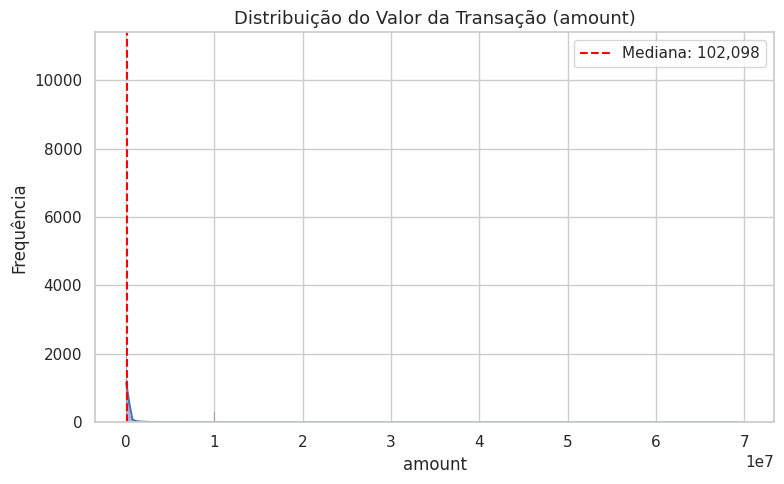

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['amount'], kde=True, color='#4C72B0', edgecolor='white')
plt.axvline(df['amount'].median(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mediana: {df["amount"].median():,.0f}')
plt.title('Distribuição do Valor da Transação (amount)', fontsize=13)
plt.xlabel('amount')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

Foi preciso ajustar para a escala logarítmica, porque ela "estica" os valores baixos e "comprime" os valores gigantes, permitindo que seja possível visualizar em um único gráfico sem aquele espaço vazio enorme demonstrado acima.

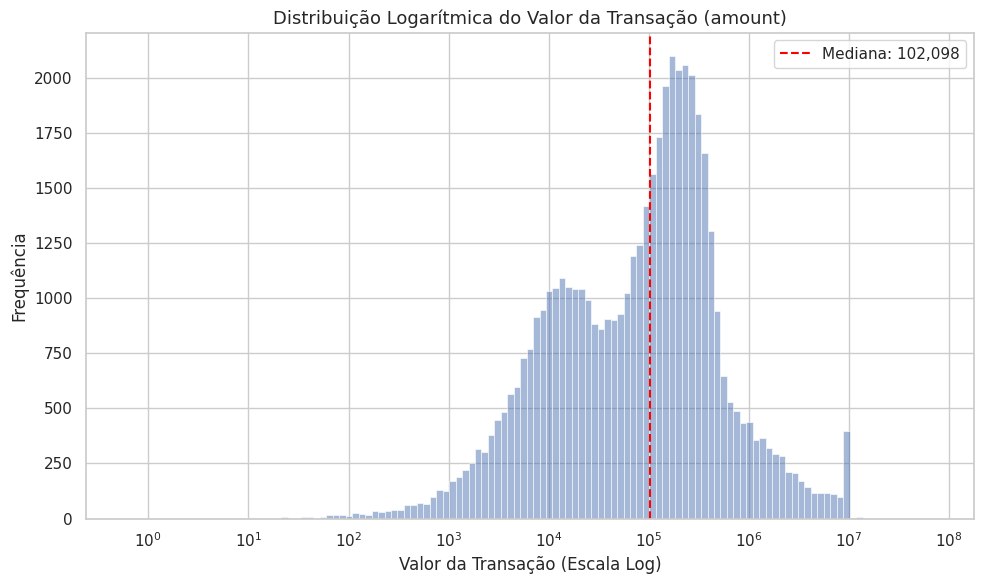

In [ ]:
plt.figure(figsize=(10, 6))

# O segredo está no log_scale=True
sns.histplot(df['amount'], kde=True, log_scale=True, color='#4C72B0', edgecolor='white')

# Adicionando a linha da mediana (precisamos garantir que ela acompanhe a escala log)
mediana = df['amount'].median()
plt.axvline(mediana, color='red', linestyle='--', linewidth=1.5,
            label=f'Mediana: {mediana:,.0f}')

plt.title('Distribuição Logarítmica do Valor da Transação (amount)', fontsize=13)
plt.xlabel('Valor da Transação (Escala Log)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

#### oldbalanceOrg

O `oldbalanceOrg` representa o saldo da conta de origem **antes** da transação — quanto dinheiro o cliente tinha disponível no momento da operação. Se a Hipótese 3 estiver correta, esperamos que transações fraudulentas ocorram em contas com saldos mais elevados.

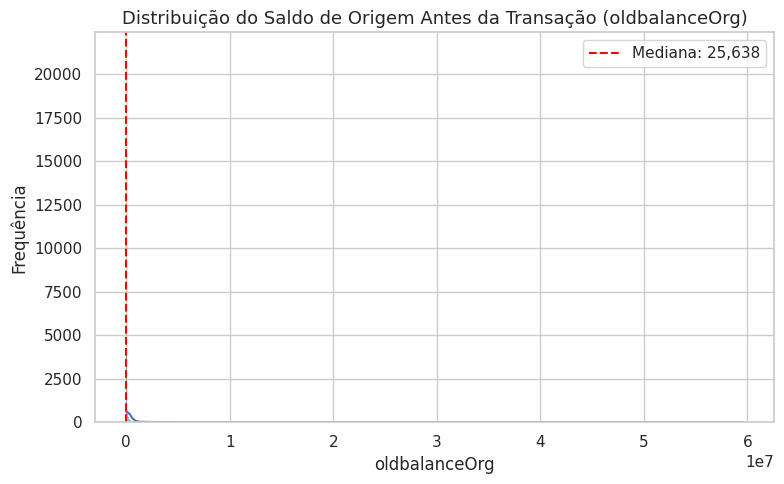

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['oldbalanceOrg'], kde=True, color='#4C72B0', edgecolor='white')
plt.axvline(df['oldbalanceOrg'].median(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mediana: {df["oldbalanceOrg"].median():,.0f}')
plt.title('Distribuição do Saldo de Origem Antes da Transação (oldbalanceOrg)', fontsize=13)
plt.xlabel('oldbalanceOrg')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

O `oldbalanceOrg` apresenta o mesmo padrão de `amount`: distribuição extremamente assimétrica à direita, com pico pronunciado próximo de zero e cauda longa para valores altos. A mediana muito baixa em relação à média confirma que a maioria dos clientes tem saldo modesto, enquanto valores extremos (contas com dezenas de milhões) puxam a média para cima. **Ponto de atenção:** o pico em zero indica que muitas transações partem de contas sem saldo prévio — comportamento que, combinado com um alto valor de transação, pode ser um indicador de fraude.

Esse gráfico está “achatado” porque outliers muito altos puxam o eixo x e esmagam a massa principal perto de zero.

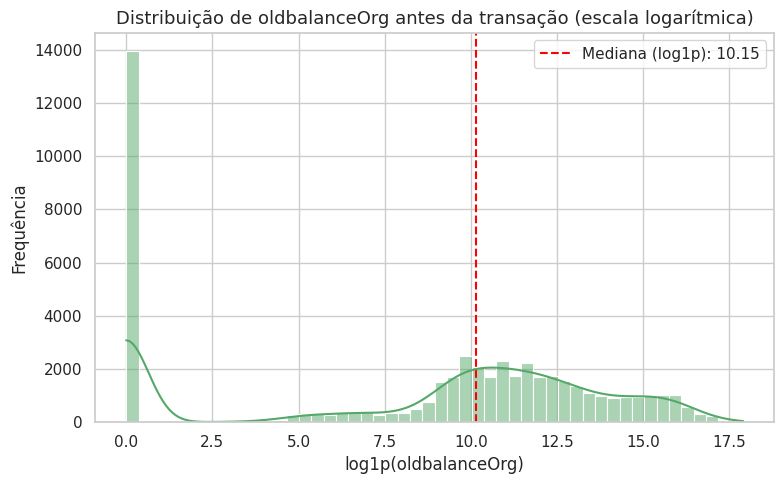

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

serie_log = np.log1p(df['oldbalanceOrg'])
mediana_log = serie_log.median()

plt.figure(figsize=(8, 5))
sns.histplot(
    serie_log,
    kde=True,
    bins=50,
    color='#55A868',
    edgecolor='white'
)

plt.axvline(
    mediana_log,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mediana (log1p): {mediana_log:.2f}'
)

plt.title('Distribuição de oldbalanceOrg antes da transação (escala logarítmica)', fontsize=13)
plt.xlabel('log1p(oldbalanceOrg)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

#### newbalanceOrig

O `newbalanceOrig` representa o saldo da conta de origem **após** a transação. Junto com `oldbalanceOrg`, permite saber quanto foi retirado da conta. A Hipótese 2 prevê que fraudes zeram esse saldo — esperamos que `newbalanceOrig` seja zero com muito mais frequência em transações fraudulentas.

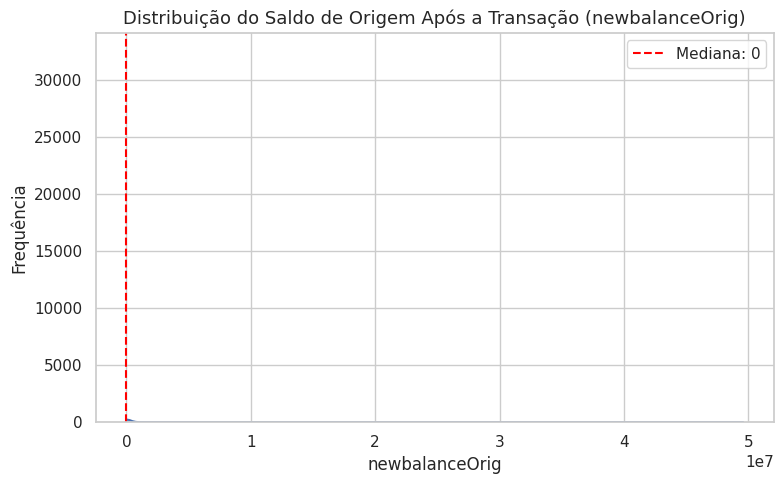

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['newbalanceOrig'], kde=True, color='#4C72B0', edgecolor='white')
plt.axvline(df['newbalanceOrig'].median(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mediana: {df["newbalanceOrig"].median():,.0f}')
plt.title('Distribuição do Saldo de Origem Após a Transação (newbalanceOrig)', fontsize=13)
plt.xlabel('newbalanceOrig')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

O `newbalanceOrig` apresenta distribuição ainda mais concentrada em zero do que `oldbalanceOrg`: o pico inicial é mais alto e mais estreito. A mediana sendo zero (linha vermelha na origem) é um achado relevante: metade de todas as transações resulta em saldo zero na conta de origem. Embora o saldo zerado seja comum em transações legítimas (ex: pagamento de conta pelo valor exato), a análise por classe confirmará que a proporção é significativamente maior nas fraudes — antecipando a confirmação da Hipótese 2. **Ponto de atenção:** essa variável terá baixa variância nas fraudes, tornando-a potencialmente muito discriminativa.

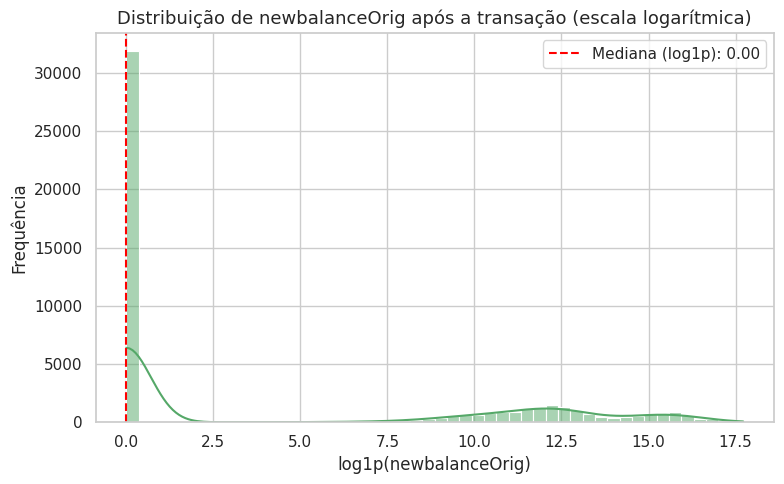

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

serie_log = np.log1p(df['newbalanceOrig'])
mediana_log = serie_log.median()

plt.figure(figsize=(8, 5))
sns.histplot(
    serie_log,
    kde=True,
    bins=50,
    color='#55A868',
    edgecolor='white'
)

plt.axvline(
    mediana_log,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mediana (log1p): {mediana_log:.2f}'
)

plt.title('Distribuição de newbalanceOrig após a transação (escala logarítmica)', fontsize=13)
plt.xlabel('log1p(newbalanceOrig)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

A visualização original de newbalanceOrig ficou fortemente concentrada próxima de zero porque essa variável combina dois comportamentos ao mesmo tempo: uma grande quantidade de valores exatamente iguais a zero e alguns valores muito altos. Como consequência, a escala do eixo x é ampliada para acomodar os extremos, comprimindo visualmente a maior parte das observações no início do gráfico. Para contornar esse problema e tornar a distribuição mais legível, foi utilizada a transformação log1p, que preserva os zeros (log1p(0)=0) e comprime os valores elevados. Assim, o histograma passa a representar com mais clareza a concentração de saldos zerados após a transação, ao mesmo tempo em que reduz o efeito visual causado pelos outliers.

#### oldbalanceDest

O `oldbalanceDest` representa o saldo da conta de **destino** antes de receber a transferência. Esta variável é central para a Hipótese 4: se contas de destino em fraudes costumam ter saldo zero, isso caracteriza as 'contas mula' — abertas especificamente para receber fundos ilícitos.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


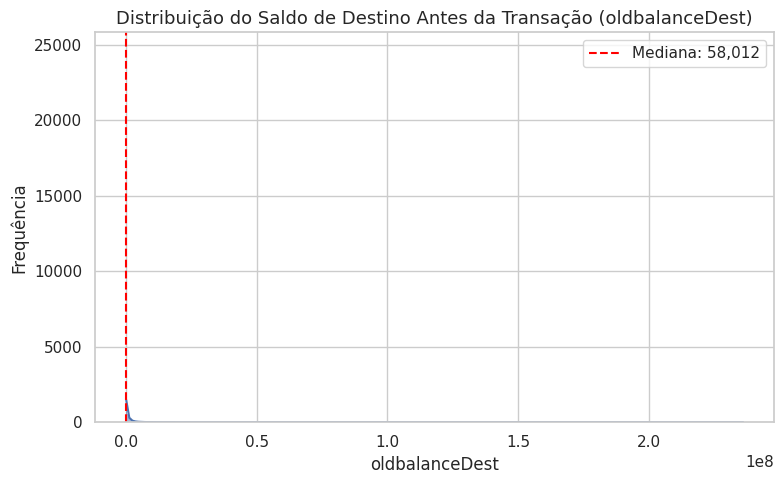

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['oldbalanceDest'], kde=True, color='#4C72B0', edgecolor='white')
plt.axvline(df['oldbalanceDest'].median(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mediana: {df["oldbalanceDest"].median():,.0f}')
plt.title('Distribuição do Saldo de Destino Antes da Transação (oldbalanceDest)', fontsize=13)
plt.xlabel('oldbalanceDest')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

O `oldbalanceDest` exibe o padrão mais extremo de todos os saldos: pico máximo em zero e cauda muito longa à direita. A mediana em zero significa que ao menos metade das contas de destino não tinha saldo antes de receber a transferência. A curtose elevadíssima calculada anteriormente reflete exatamente esse comportamento: quase tudo está em zero, com valores extremos muito altos formando a cauda. **Ponto de atenção:** a moda de zero é um sinal importante para a Hipótese 4 — investigaremos se essa proporção é ainda maior nas fraudes especificamente.

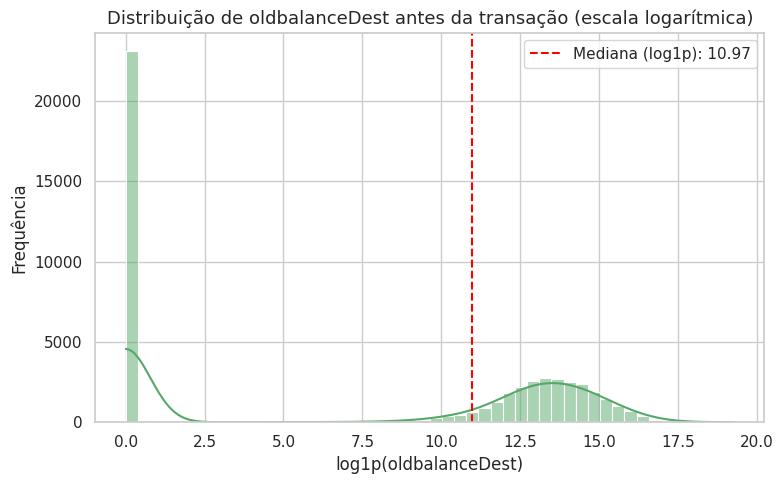

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

serie_log = np.log1p(df['oldbalanceDest'])
mediana_log = serie_log.median()

plt.figure(figsize=(8, 5))
sns.histplot(
    serie_log,
    kde=True,
    bins=50,
    color='#55A868',
    edgecolor='white'
)

plt.axvline(
    mediana_log,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mediana (log1p): {mediana_log:.2f}'
)

plt.title('Distribuição de oldbalanceDest antes da transação (escala logarítmica)', fontsize=13)
plt.xlabel('log1p(oldbalanceDest)')
plt.ylabel('Frequência')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

A visualização original de oldbalanceDest ficou fortemente comprimida próxima de zero porque essa variável apresenta um padrão extremo de concentração em valores muito baixos, incluindo muitos casos iguais a zero, combinado com poucos valores muito altos. Como o histograma precisa acomodar toda a amplitude dos dados, os outliers expandem excessivamente a escala do eixo x e acabam achatando visualmente a massa principal das observações. Para tornar a distribuição mais legível, foi aplicada a transformação log1p, que preserva os valores zero e comprime os extremos elevados. Com isso, o gráfico passa a representar de forma mais clara a forte concentração inicial de saldos de destino baixos, ao mesmo tempo em que reduz o efeito visual da cauda longa à direita.

#### newbalanceDest

O `newbalanceDest` representa o saldo da conta de destino **após** receber a transferência. Junto com `oldbalanceDest` e `amount`, forma o trio que descreve o fluxo financeiro completo. Em fraudes, esperamos que este valor seja alto — os recursos extraídos da conta de origem chegam integralmente à conta mula.

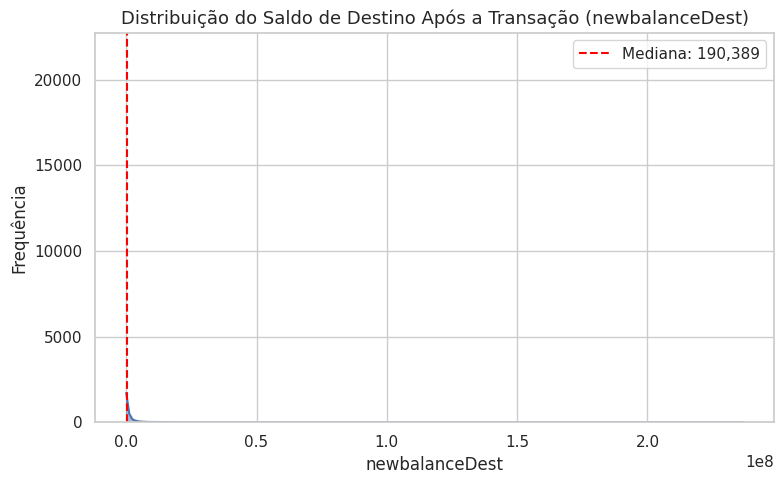

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['newbalanceDest'], kde=True, color='#4C72B0', edgecolor='white')
plt.axvline(df['newbalanceDest'].median(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mediana: {df["newbalanceDest"].median():,.0f}')
plt.title('Distribuição do Saldo de Destino Após a Transação (newbalanceDest)', fontsize=13)
plt.xlabel('newbalanceDest')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

O `newbalanceDest` apresenta distribuição semelhante a `oldbalanceDest`, com pico em zero ligeiramente menor e cauda mais distribuída — algumas contas de destino terminam com saldos altos. A alta correlação entre `oldbalanceDest` e `newbalanceDest` (identificada na matriz de correlação) indica multicolinearidade que pode prejudicar modelos lineares. **Ponto de atenção:** essa relação entre as duas variáveis de saldo de destino já foi antecipada na engenharia de features com a criação de `diff_saldo_dest`, que captura a variação líquida de forma mais informativa.

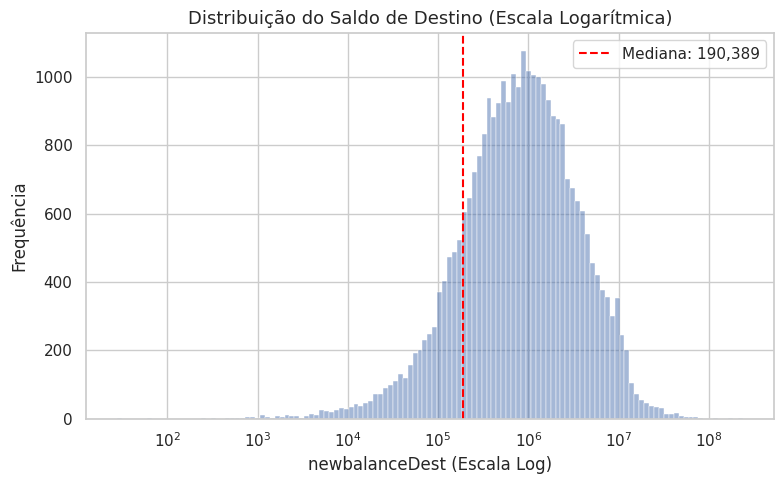

In [ ]:
plt.figure(figsize=(8, 5))

# Alteração: Adicionado log_scale=True para lidar com a grande amplitude de valores
sns.histplot(df['newbalanceDest'], kde=True, color='#4C72B0', edgecolor='white', log_scale=True)

# A linha da mediana precisa ser calculada, mas como o eixo X agora é log,
# a visualização ficará muito mais clara.
mediana = df['newbalanceDest'].median()
plt.axvline(mediana, color='red', linestyle='--', linewidth=1.5,
            label=f'Mediana: {mediana:,.0f}')

plt.title('Distribuição do Saldo de Destino (Escala Logarítmica)', fontsize=13)
plt.xlabel('newbalanceDest (Escala Log)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

A mudança para a escala logarítmica no histograma acima resolveu o problema da "linha única" e permitiu que a visualização de fato suporte o que está escrito no texto. Agora conseguimos ver o formato real da massa de dados. Antes, tudo parecia ser zero; agora é possível perceber que existe uma concentração em torno de valores específicos e como a frequência decai. O eixo X agora mostra de forma clara os valores que vão de $10^2$ até $10^8$. Isso ilustra perfeitamente o comentário sobre "algumas contas de destino terminarem com saldos altos" sem esconder o resto dos dados.

#### step

O `step` representa a unidade de tempo da simulação: cada step equivale a 1 hora, cobrindo 744 horas (30 dias). Diferentemente das variáveis financeiras, esperamos distribuição distinta — mais uniforme, já que transações ocorrem ao longo de todo o período simulado.

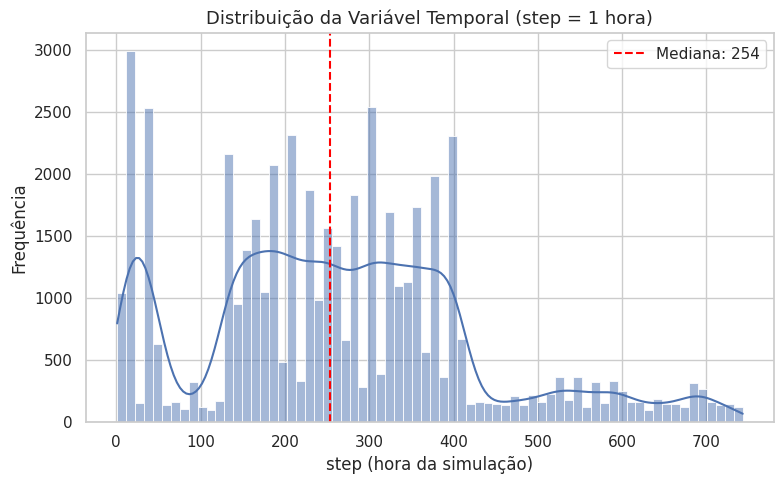

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['step'], kde=True, color='#4C72B0', edgecolor='white')
plt.axvline(df['step'].median(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mediana: {df["step"].median():,.0f}')
plt.title('Distribuição da Variável Temporal (step = 1 hora)', fontsize=13)
plt.xlabel('step (hora da simulação)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

Como esperado, `step` apresenta distribuição aproximadamente uniforme — transações ocorrem de forma relativamente constante ao longo dos 30 dias, sem concentração em períodos específicos. A mediana está próxima do centro do intervalo, confirmando cobertura temporal equilibrada. Observam-se pequenas oscilações que podem refletir ciclos diários ou semanais. **Ponto de atenção:** `step` é a única variável com distribuição próxima da uniforme, contrastando fortemente com todas as demais. Sua baixa correlação linear com `isFraud` não descarta utilidade — features derivadas como `step % 24` (hora do dia) ou `step // 24` (dia do mês) poderiam capturar padrões temporais não-lineares em etapa futura de engenharia de features.

### Histogramas Comparativos — Fraude vs. Legítima

Visualizar as distribuições separadas por classe é uma das análises mais valiosas da EDA para problemas de classificação. Se as distribuições das duas classes se sobrepõem completamente, a variável tem pouco poder discriminativo. Se elas se separam claramente, a variável será provavelmente importante para o modelo. Aplicamos a transformação `log1p` antes de plotar — não por ser o pré-processamento final, mas para que as distribuições fiquem visíveis na mesma escala, dado o alto grau de assimetria dos dados brutos. Analisamos as 4 variáveis financeiras mais relevantes para as hipóteses 2, 3 e 4.

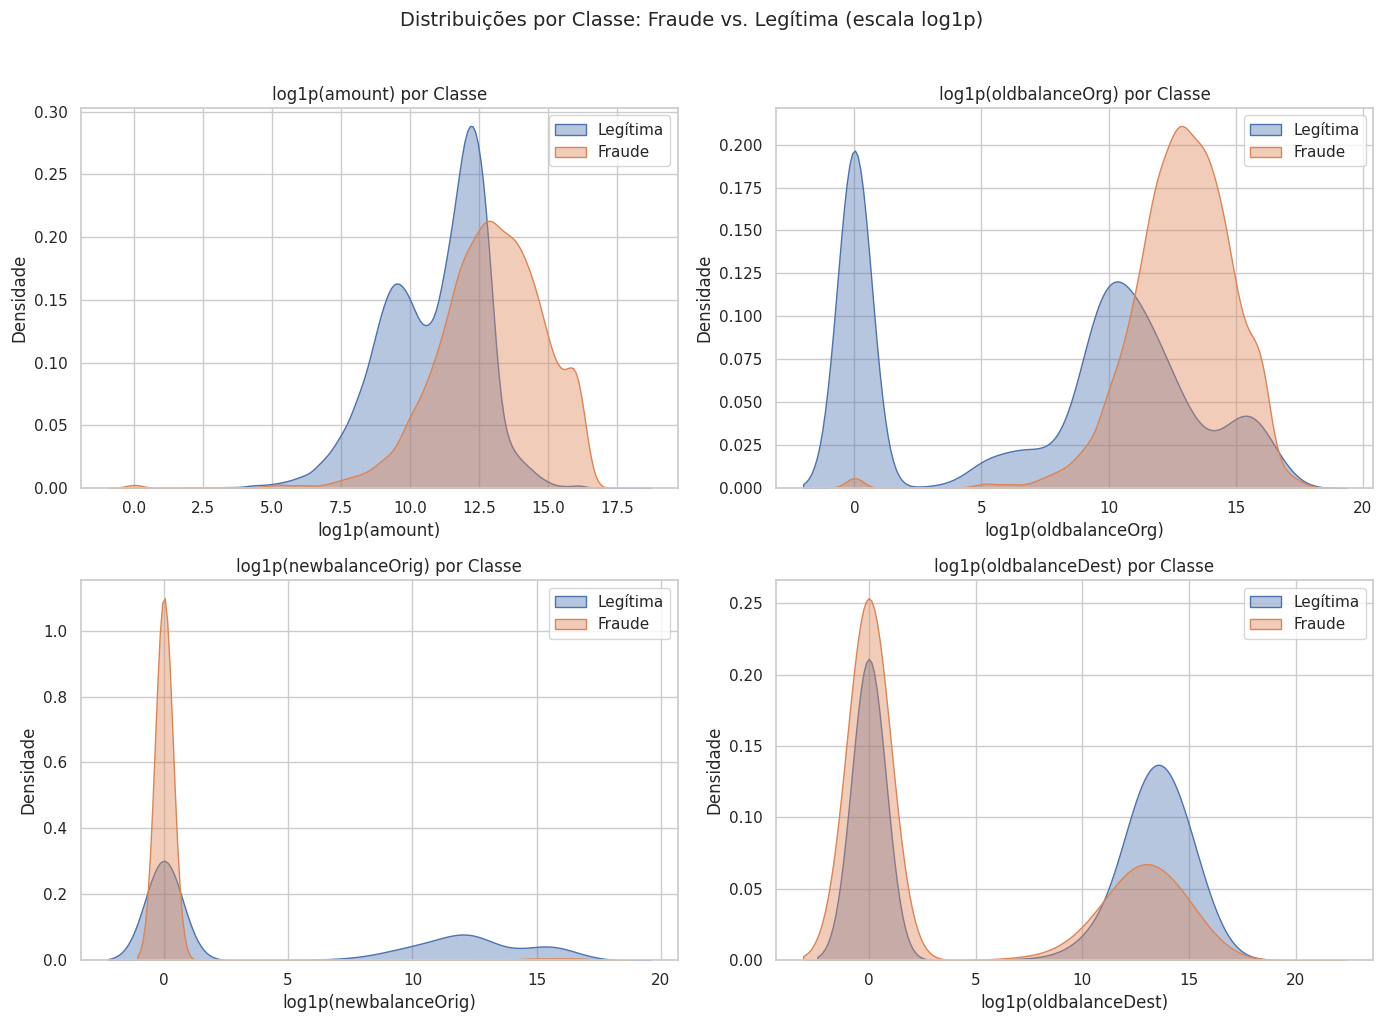

In [ ]:
# gráficos KDE sobrepostos: fraude (laranja) vs. legítima (azul) — escala log1p para legibilidade
colunas_comparar = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest']
cores_classe     = {0: '#4C72B0', 1: '#DD8452'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(colunas_comparar):
    for label, grupo in df.groupby('isFraud')[col]:
        nome = 'Fraude' if label == 1 else 'Legítima'
        sns.kdeplot(np.log1p(grupo), ax=axes[i],
                    label=nome, fill=True, alpha=0.4,
                    color=cores_classe[label])
    axes[i].set_title(f'log1p({col}) por Classe', fontsize=12)
    axes[i].set_xlabel(f'log1p({col})')
    axes[i].set_ylabel('Densidade')
    axes[i].legend()

plt.suptitle('Distribuições por Classe: Fraude vs. Legítima (escala log1p)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

####log1p(amount) (Valor da Transação)

Transações fraudulentas tendem a ter valores mais elevados e concentrados em uma faixa específica. Enquanto transações legítimas variam muito (muitos valores baixos), a fraude parece ter um "alvo" de valor mais alto para valer o esforço do criminoso.

####log1p(oldbalanceOrg) (Saldo Inicial da Origem)
Nas transações legítimas, há um pico enorme perto de zero. Nas fraudes, a densidade é muito maior em valores altos (entre 10 e 15 na escala log). Esta é uma variável fortemente preditiva. Ela indica que as fraudes ocorrem majoritariamente em contas que possuem saldos altos. Contas com pouco dinheiro raramente são alvos de fraude neste dataset.

####log1p(newbalanceOrig) (Saldo Final da Origem)
O gráfico de fraude mostra um pico extremamente agudo no zero. Isso confirma um comportamento clássico de fraude: o criminoso tenta esvaziar a conta completamente. Enquanto nas transações legítimas o saldo restante varia, na fraude, o saldo final da conta de origem quase sempre chega a zero.

####log1p(oldbalanceDest) (Saldo Inicial do Destino)
Ambas as classes possuem um pico em zero, mas a distribuição legítima tem um segundo "calombo" mais definido à direita. Curiosamente, muitas fraudes são enviadas para contas de destino que também começam com saldo zerado (possivelmente contas "laranjas" recém-criadas).

####As variáveis mais valiosas para o modelo de Machine Learning serão:
newbalanceOrig: Pela clara tendência da fraude em zerar a conta.

oldbalanceOrg: Pela preferência de fraudadores por contas com saldos recheados.

amount: Pelo ticket médio mais elevado das fraudes.

### Boxplots — Detecção de Outliers e Comparação por Classe

Os boxplots sintetizam em uma única visualização cinco estatísticas: mínimo não-outlier (whisker inferior), primeiro quartil (Q1, borda inferior da caixa), mediana (linha central), terceiro quartil (Q3, borda superior) e máximo não-outlier (whisker superior). Pontos além dos whiskers são outliers (>1,5× IQR). Ao separar por classe (isFraud), comparamos diretamente as distribuições de cada variável entre fraudes e legítimas. Usamos escala log1p para garantir que ambas as classes sejam visíveis sem que os valores extremos comprima os demais. Complementamos com uma análise quantitativa de outliers pelo método IQR.

#### amount por Classe

Comparamos a distribuição de `amount` entre transações legítimas e fraudulentas. Se a Hipótese 3 estiver correta, a caixa laranja (fraudes) deverá estar posicionada mais alto, indicando que fraudes envolvem valores maiores. A escala log1p é aplicada para garantir que ambas as classes sejam visíveis sem compressão pelos valores extremos.

/tmp/ipykernel_5695/1307195015.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bp, x='isFraud', y='amount',


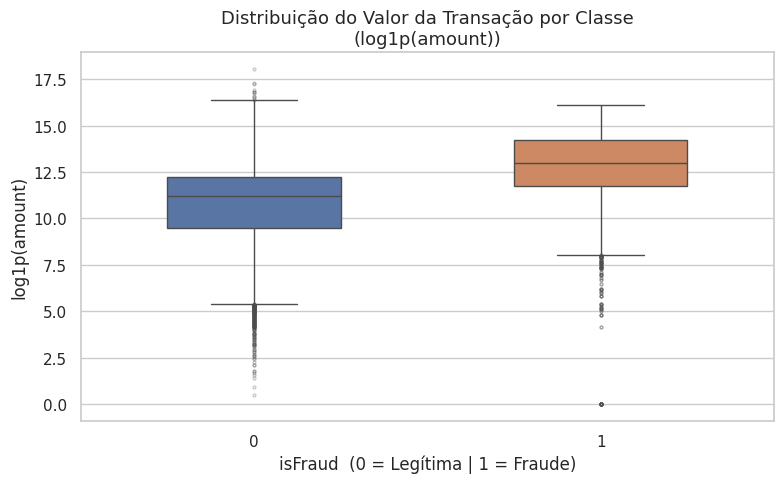

In [ ]:
df_bp = df.copy()
df_bp['amount'] = np.log1p(df_bp['amount'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_bp, x='isFraud', y='amount',
            palette=['#4C72B0', '#DD8452'], width=0.5,
            flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
plt.title('Distribuição do Valor da Transação por Classe\n(log1p(amount))', fontsize=13)
plt.xlabel('isFraud  (0 = Legítima | 1 = Fraude)')
plt.ylabel('log1p(amount)')
plt.tight_layout()
plt.show()

O boxplot demonstra claramente que transações fraudulentas envolvem valores significativamente maiores. A caixa laranja (fraudes) está posicionada consideravelmente mais alto: a mediana e o intervalo interquartil (Q1 a Q3) das fraudes ocupam uma faixa de valores mais elevada do que os das legítimas. Isso confirma visualmente a **Hipótese 3**. Pontos além dos whiskers são abundantes em ambas as classes, evidenciando outliers reais. **Ponto de atenção:** a sobreposição parcial das caixas indica que nem todo valor alto é necessariamente fraude — `amount` isolado não classifica, mas combinado com outras features tem alto poder discriminativo.

#### oldbalanceOrg por Classe

A ideia é investigar se o saldo de origem antes da transação difere entre as classes. A hipótese é que fraudadores selecionam intencionalmente contas com saldo mais elevado para maximizar o valor extraído.

/tmp/ipykernel_5695/2303600846.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bp2, x='isFraud', y='oldbalanceOrg',


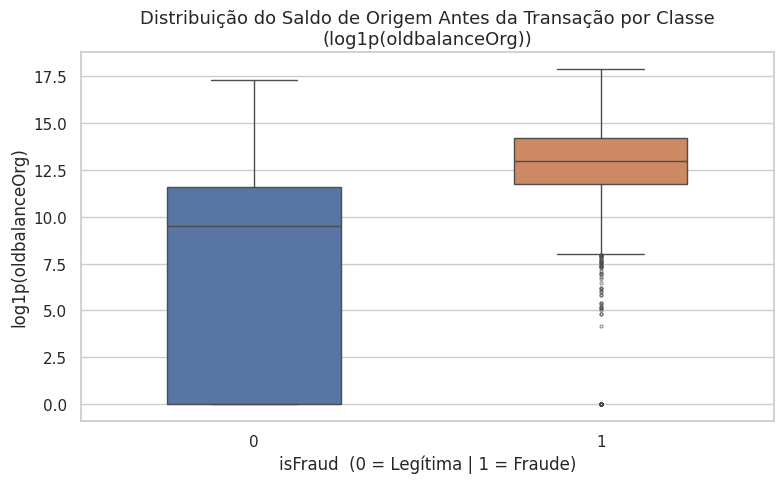

In [ ]:
df_bp2 = df.copy()
df_bp2['oldbalanceOrg'] = np.log1p(df_bp2['oldbalanceOrg'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_bp2, x='isFraud', y='oldbalanceOrg',
            palette=['#4C72B0', '#DD8452'], width=0.5,
            flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
plt.title('Distribuição do Saldo de Origem Antes da Transação por Classe\n(log1p(oldbalanceOrg))', fontsize=13)
plt.xlabel('isFraud  (0 = Legítima | 1 = Fraude)')
plt.ylabel('log1p(oldbalanceOrg)')
plt.tight_layout()
plt.show()

O boxplot confirma que transações fraudulentas tendem a ocorrer em contas com saldos de origem mais elevados. A mediana e os quartis da caixa laranja estão consistentemente acima dos da caixa azul. Isso é coerente com a estratégia fraudulenta: escolher contas mais ricas para extrair o máximo possível em uma única operação. **Ponto de atenção:** tanto `oldbalanceOrg` quanto `amount` mostram o mesmo padrão — fraudes em faixa mais alta. A feature `razao_amount_saldo` criada na engenharia de features captura exatamente essa relação entre os dois atributos.

#### newbalanceOrig por Classe

O saldo de origem **após** a transação é a variável mais diretamente ligada à Hipótese 2. Se fraudes zeram o saldo, a caixa laranja deverá estar comprimida próxima de zero, contrastando fortemente com as legítimas.

/tmp/ipykernel_5695/3862791233.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bp3, x='isFraud', y='newbalanceOrig',


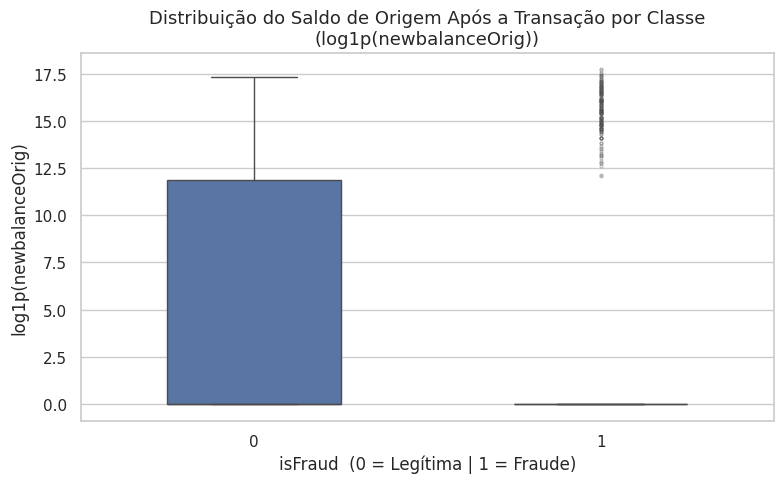

In [ ]:
df_bp3 = df.copy()
df_bp3['newbalanceOrig'] = np.log1p(df_bp3['newbalanceOrig'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_bp3, x='isFraud', y='newbalanceOrig',
            palette=['#4C72B0', '#DD8452'], width=0.5,
            flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
plt.title('Distribuição do Saldo de Origem Após a Transação por Classe\n(log1p(newbalanceOrig))', fontsize=13)
plt.xlabel('isFraud  (0 = Legítima | 1 = Fraude)')
plt.ylabel('log1p(newbalanceOrig)')
plt.tight_layout()
plt.show()

Este é um dos boxplots mais reveladores. A caixa laranja (fraudes) está completamente comprimida próxima de zero — mediana, Q1 e Q3 são todos próximos do mínimo. A esmagadora maioria das transações fraudulentas resulta em saldo de origem zero, enquanto as legítimas mostram distribuição muito mais ampla.

O boxplot do saldo de origem após a transação demonstra claramente que há diferença marcante entre as classes, **confirmando visualmente a Hipótese 2** de forma contundente. **Ponto de atenção:** a baixíssima variância de `newbalanceOrig` nas fraudes torna essa variável extremamente discriminativa para identificar a classe fraudulenta.

#### newbalanceDest por Classe

A ideia é analisar saldo da conta de destino **após** a transação. Em fraudes, esperamos que esse valor seja mais alto — o valor extraído da origem chega integralmente à conta mula de destino.

/tmp/ipykernel_5695/2354049882.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bp4, x='isFraud', y='newbalanceDest',


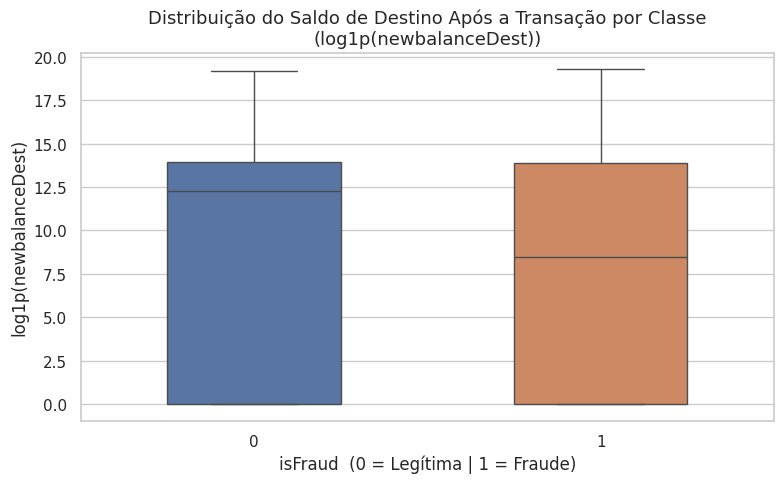

In [ ]:
df_bp4 = df.copy()
df_bp4['newbalanceDest'] = np.log1p(df_bp4['newbalanceDest'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_bp4, x='isFraud', y='newbalanceDest',
            palette=['#4C72B0', '#DD8452'], width=0.5,
            flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
plt.title('Distribuição do Saldo de Destino Após a Transação por Classe\n(log1p(newbalanceDest))', fontsize=13)
plt.xlabel('isFraud  (0 = Legítima | 1 = Fraude)')
plt.ylabel('log1p(newbalanceDest)')
plt.tight_layout()
plt.show()

O boxplot de newbalanceDest indica que, contrariamente à expectativa inicial, contas de destino em transações fraudulentas não apresentam saldos finais mais elevados do que nas legítimas. Observa-se que a mediana das transações legítimas está posicionada acima da das fraudes, enquanto estas exibem maior dispersão. Isso sugere que, embora fraudes possam envolver transferências de alto valor, o saldo final na conta de destino não permanece necessariamente elevado, possivelmente devido à rápida movimentação dos recursos após a transação inicial. Em conjunto, os boxplots ainda contribuem para a compreensão do padrão fraudulento, mas indicam que o saldo da conta de destino, isoladamente, não é um forte discriminador de fraude.

#### Análise Quantitativa de Outliers (Método IQR)

Além da visualização pelos boxplots, quantificamos formalmente o número de outliers em cada variável usando o critério IQR: valores abaixo de Q1 - 1,5×IQR ou acima de Q3 + 1,5×IQR são classificados como outliers. Essa análise complementa os boxplots com números precisos e orienta decisões de pré-processamento.

In [ ]:
print('Análise de Outliers — Método IQR (limite = Q1 - 1.5×IQR  ou  Q3 + 1.5×IQR):')
print('-' * 60)
colunas_num = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
               'oldbalanceDest', 'newbalanceDest', 'step']
for col in colunas_num:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct   = n_out / len(df) * 100
    print(f'{col:20s}: {n_out:6,} outliers  ({pct:.2f}% do total)')

Análise de Outliers — Método IQR (limite = Q1 - 1.5×IQR  ou  Q3 + 1.5×IQR):
------------------------------------------------------------
amount              :  4,958 outliers  (9.92% do total)
oldbalanceOrg       :  8,795 outliers  (17.59% do total)
newbalanceOrig      :  9,159 outliers  (18.32% do total)
oldbalanceDest      :  6,495 outliers  (12.99% do total)
newbalanceDest      :  5,887 outliers  (11.77% do total)
step                :  1,509 outliers  (3.02% do total)


A análise IQR confirma percentuais expressivos de outliers nas variáveis financeiras. É fundamental ressaltar que esses outliers são **eventos reais** do sistema — transações de alto valor existem genuinamente. Removê-los seria inadequado: poderia eliminar exatamente as fraudes que queremos detectar. A variável `step` apresenta poucos outliers, coerente com sua distribuição uniforme. **Ponto de atenção:** esses resultados reforçam a inadequação do StandardScaler (sensível à média e desvio padrão, afetados por extremos) e fundamentam a inclusão do **RobustScaler** (baseado em mediana e IQR, resistente a outliers) como opção de pré-processamento na etapa seguinte.

### Análise Temporal — Distribuição ao Longo do Tempo

O atributo `step` representa horas da simulação (1 step = 1 hora, total 744h = 30 dias). Investigamos se existe padrão temporal que diferencie fraudes de transações legítimas — por exemplo, se fraudes ocorrem mais à noite, em finais de semana ou em surtos concentrados. Essa análise é relevante porque um padrão temporal forte poderia justificar a criação de features derivadas (hora do dia, dia da semana) na engenharia de features. Plotamos as séries separadamente para visualizar os padrões de cada classe sem interferência de escala.

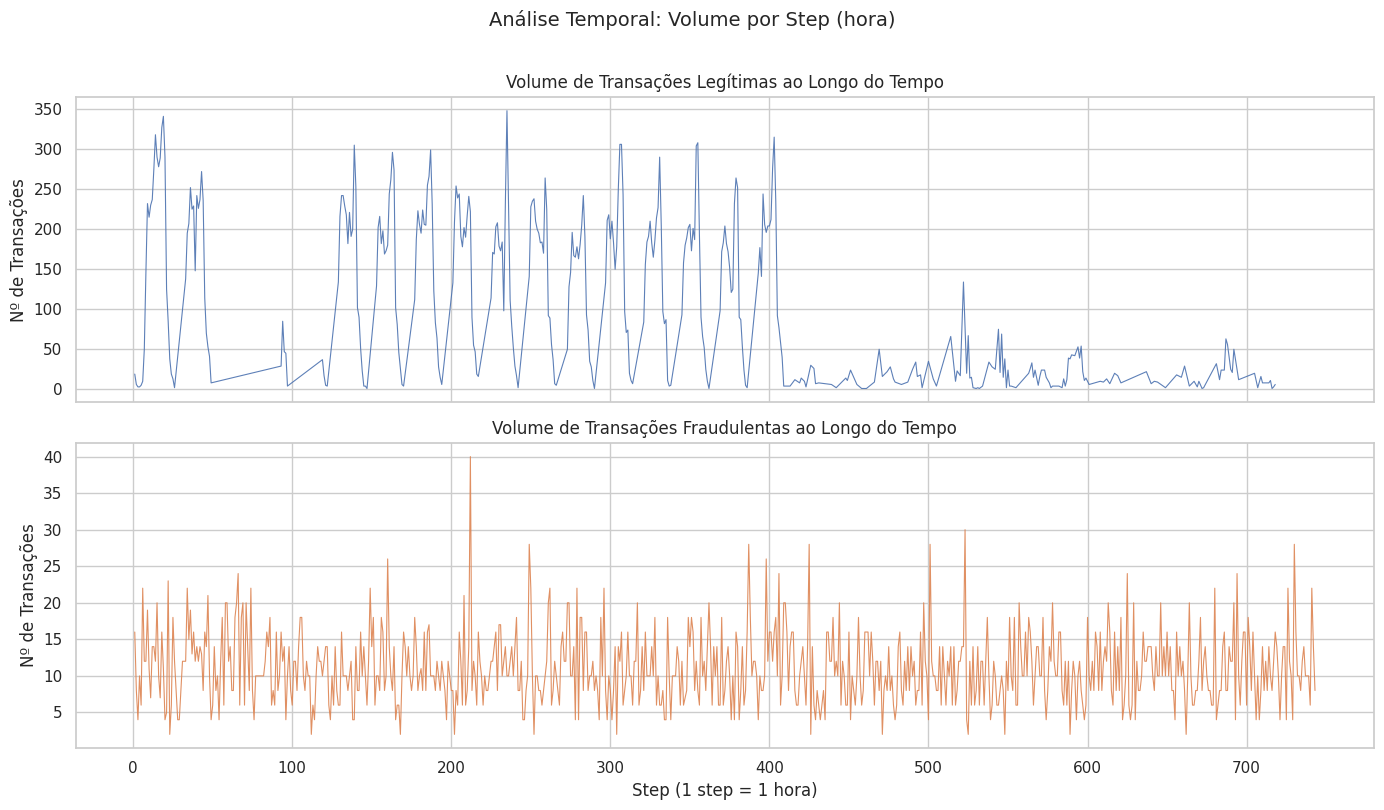

In [ ]:
# volume de transações por step, separado por classe para comparação visual
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# transações legítimas
df[df['isFraud'] == 0].groupby('step').size().plot(
    ax=axes[0], color='#4C72B0', linewidth=0.8, alpha=0.9
)
axes[0].set_title('Volume de Transações Legítimas ao Longo do Tempo', fontsize=12)
axes[0].set_ylabel('Nº de Transações')

# transações fraudulentas
df[df['isFraud'] == 1].groupby('step').size().plot(
    ax=axes[1], color='#DD8452', linewidth=0.8, alpha=0.9
)
axes[1].set_title('Volume de Transações Fraudulentas ao Longo do Tempo', fontsize=12)
axes[1].set_xlabel('Step (1 step = 1 hora)')
axes[1].set_ylabel('Nº de Transações')

plt.suptitle('Análise Temporal: Volume por Step (hora)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

As transações legítimas apresentam um comportamento cíclico bem definido no início da série, possivelmente refletindo padrões diários de uso. No entanto, observa-se uma mudança significativa após aproximadamente o step 400, com queda acentuada no volume e maior irregularidade, indicando possível alteração no regime dos dados.

Já as transações fraudulentas se distribuem de forma relativamente constante ao longo do tempo, com variações moderadas e alguns picos ocasionais, mas sem evidência clara de concentração em períodos específicos ou padrões temporais fortes.

Embora a correlação linear entre step e isFraud seja baixa, transformações temporais como step % 24 (hora do dia) ou step // 24 (dia) podem revelar padrões não-lineares mais sutis e são boas candidatas para engenharia de features.

### Análise do Saldo Zerado na Origem — Hipótese 2

Para verificar quantitativamente a Hipótese 2 (fraudes zeram o saldo de origem), foi criado uma feature auxiliar binária: `saldo_orig_zerado = 1` quando `newbalanceOrig == 0`. Essa abordagem transforma uma observação qualitativa ('fraudes parecem zerar o saldo') em uma pergunta mensurável ('qual a proporção de cada classe que resulta em saldo zero?'). A feature auxiliar criada aqui também será incorporada ao dataset final de modelagem.

In [ ]:
# criação de feature auxiliar para verificar a Hipótese 2
df['saldo_orig_zerado'] = (df['newbalanceOrig'] == 0).astype(int)

# proporção de saldo zerado por classe
zerado_por_classe = df.groupby('isFraud')['saldo_orig_zerado'].mean() * 100
zerado_por_classe.index = ['Legítima', 'Fraude']

print('Proporção (%) que zeraram o saldo de origem por classe:')
print(zerado_por_classe.round(2))
print(f'\nFraudes zeram saldo {zerado_por_classe["Fraude"]/zerado_por_classe["Legítima"]:.1f}x mais que legítimas.')

Proporção (%) que zeraram o saldo de origem por classe:
Legítima   56.9600
Fraude     98.0500
Name: saldo_orig_zerado, dtype: float64

Fraudes zeram saldo 1.7x mais que legítimas.


Para visualizar essa diferença de forma imediata, foi construído um gráfico de barras comparando a proporção de saldo zerado entre as duas classes. Esse tipo de gráfico é ideal quando queremos comparar um percentual entre grupos distintos — a altura de cada barra representa diretamente a proporção da respectiva classe.

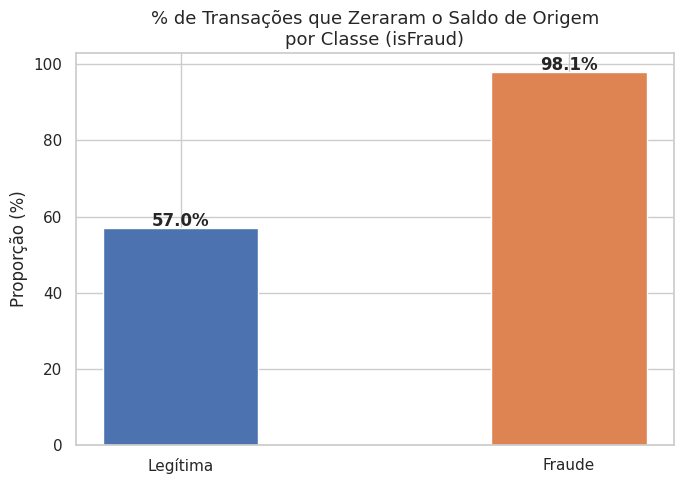

In [ ]:
# visualização: comparação da proporção de saldo zerado entre as classes
plt.figure(figsize=(7, 5))
bars = plt.bar(zerado_por_classe.index, zerado_por_classe.values,
               color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
plt.title('% de Transações que Zeraram o Saldo de Origem\npor Classe (isFraud)', fontsize=13)
plt.ylabel('Proporção (%)')
for bar, v in zip(bars, zerado_por_classe.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5,
             f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

O gráfico confirma expressiva diferença entre as classes: fraudes zeram o saldo de origem com frequência muito maior. Esse comportamento reflete a lógica do fraudador — extrair o máximo de recursos em uma única operação. A feature `saldo_orig_zerado` tem correlação expressiva com `isFraud` e tende a ser selecionada como variável relevante por modelos baseados em importância de features como Random Forest e XGBoost.

### Análise do Saldo do Destinatário — Hipótese 4

De forma análoga à análise anterior, é possível investigar a Hipótese 4 (contas mula). Foi criado a feature `dest_saldo_zero_antes = 1` quando `oldbalanceDest == 0`. A pergunta que buscamos responder é: contas de destino em transações fraudulentas costumam estar vazias antes de receber os fundos? Se sim, isso caracteriza o uso de contas criadas especificamente para esse fim.

In [ ]:
# criação de feature auxiliar para verificar a Hipótese 4
df['dest_saldo_zero_antes'] = (df['oldbalanceDest'] == 0).astype(int)

dest_zero_por_classe = df.groupby('isFraud')['dest_saldo_zero_antes'].mean() * 100
dest_zero_por_classe.index = ['Legítima', 'Fraude']

print('Proporção (%) com saldo zero no destinatário antes da transação:')
print(dest_zero_por_classe.round(2))
print(f'\nFraudes têm destino com saldo zero {dest_zero_por_classe["Fraude"]/dest_zero_por_classe["Legítima"]:.1f}x mais que legítimas.')

Proporção (%) com saldo zero no destinatário antes da transação:
Legítima   42.4900
Fraude     65.1500
Name: dest_saldo_zero_antes, dtype: float64

Fraudes têm destino com saldo zero 1.5x mais que legítimas.


Assim como na análise da Hipótese 2, é possível visualizar a proporção de conta de destino com saldo zero entre as classes com um gráfico de barras. A comparação direta das duas barras permite avaliar rapidamente a magnitude da diferença e fundamentar a confirmação ou refutação da hipótese.

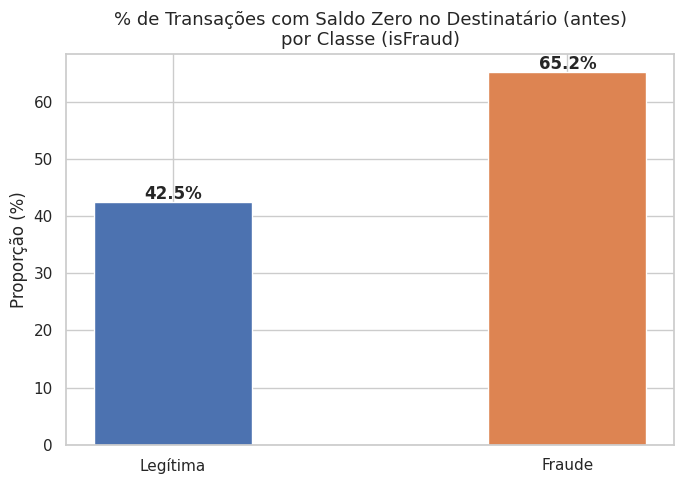

In [ ]:
# visualização: comparação da proporção de conta de destino vazia entre as classes
plt.figure(figsize=(7, 5))
bars = plt.bar(dest_zero_por_classe.index, dest_zero_por_classe.values,
               color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
plt.title('% de Transações com Saldo Zero no Destinatário (antes)\npor Classe (isFraud)', fontsize=13)
plt.ylabel('Proporção (%)')
for bar, v in zip(bars, dest_zero_por_classe.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5,
             f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

A diferença é expressiva e confirma a Hipótese 4: contas de destino vazias antes da transação são muito mais comuns em fraudes. Esse é o padrão das contas mula — abertas ou controladas especificamente para receber recursos ilícitos. Ponto de atenção: também há transações legítimas com destino em saldo zero — primeiros recebimentos de contas novas. Por isso, essa feature deve ser usada em combinação com outras para evitar excesso de falsos positivos.

## Matriz de Correlação

A matriz de correlação de Pearson mede a força e direção das relações **lineares** entre pares de variáveis numéricas. Valores próximos a +1 indicam forte correlação positiva, a -1 forte negativa, e a 0 ausência de relação linear. Dois usos principais aqui: (1) identificar quais variáveis têm relação linear com `isFraud` (orienta a seleção de features para modelagem) e (2) identificar multicolinearidade entre features (relevante para algoritmos como regressão logística). Importante: correlação linear baixa não significa que uma variável é inútil — modelos não-lineares podem capturar relações que Pearson não mensura.

In [ ]:
# correlações com isFraud ordenadas por valor absoluto — ranking de relevância linear
colunas_corr = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

matriz_corr = df[colunas_corr].corr()
print('Correlações com isFraud (ordenado por valor absoluto):')
print(matriz_corr['isFraud'].drop('isFraud').abs().sort_values(ascending=False).round(4))

Correlações com isFraud (ordenado por valor absoluto):
amount           0.3843
step             0.2833
oldbalanceOrg    0.1037
newbalanceOrig   0.0869
oldbalanceDest   0.0597
isFlaggedFraud   0.0404
newbalanceDest   0.0054
Name: isFraud, dtype: float64


`isFlaggedFraud` tem a maior correlação com `isFraud`, mas será removida por causar data leakage. Das variáveis disponíveis para uso, `amount` e `oldbalanceOrg` são as mais correlacionadas — alinhado com os achados dos histogramas e boxplots. `step` tem correlação muito baixa, confirmando que o momento temporal isolado não é um bom preditor linear de fraude.

Para visualizar todas as correlações simultaneamente, foi feito um heatmap triangular com mapa de cores divergente (coolwarm): vermelho para correlações positivas, azul para negativas, e branco para ausência de correlação. Foi usado apenas o triângulo inferior para evitar redundância (a matriz é simétrica).

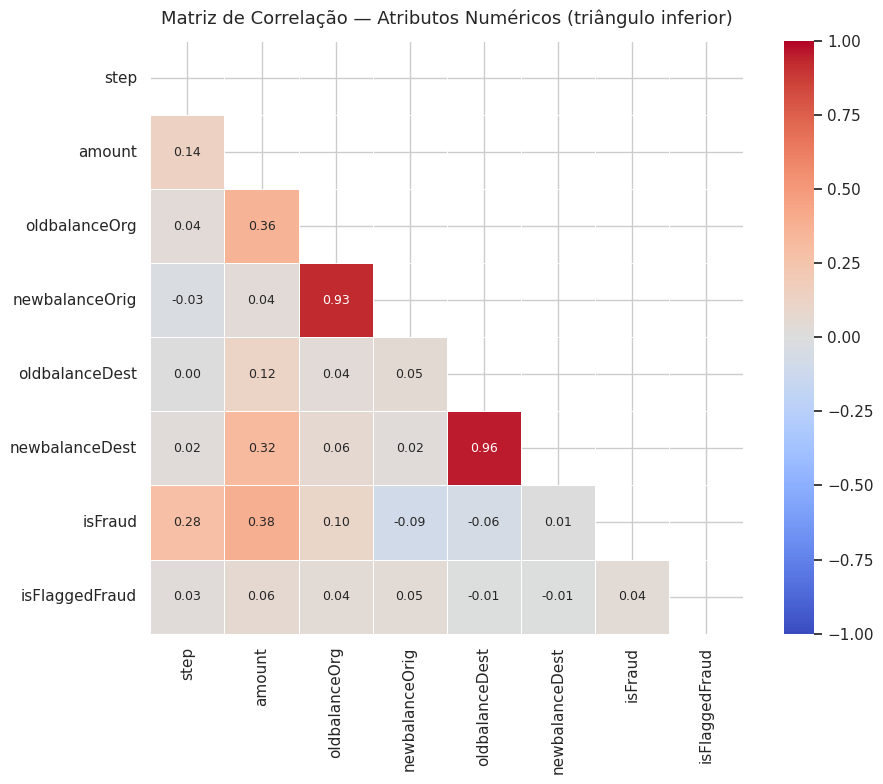

In [ ]:
# heatmap triangular — visualização simultânea de todas as correlações
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 9}, square=True
)
plt.title('Matriz de Correlação — Atributos Numéricos (triângulo inferior)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

O heatmap revela correlação muito alta entre oldbalanceDest e newbalanceDest, indicando multicolinearidade esperada, já que o saldo final é derivado do saldo inicial após a transação.

Em relação à variável alvo (isFraud), observa-se uma correlação moderada com amount, sugerindo que transações de maior valor estão mais associadas a fraudes. Por outro lado, variáveis como oldbalanceOrg apresentam correlação fraca, enquanto newbalanceOrig possui correlação negativa muito baixa, não sendo suficientemente relevante para conclusões isoladas.

A variável isFlaggedFraud apresenta correlação praticamente nula com isFraud, indicando baixa efetividade do sistema baseado em regras. De forma geral, as relações lineares observadas são limitadas, reforçando a necessidade de abordagens mais sofisticadas para detecção de fraudes.

### Análise de Pares (Pairplot)

O pairplot exibe simultaneamente as distribuições individuais (diagonal) e as relações entre pares de variáveis (fora da diagonal), colorindo cada ponto pela classe. É a análise mais abrangente para avaliar a **separabilidade multivariada** do dataset: se as classes se separam em alguma combinação de variáveis, um modelo de classificação terá espaço para aprender esse padrão. Como as fraudes representam apenas 1,2% do dataset, usamos uma **amostra balanceada** para o pairplot (todas as fraudes + 5× mais legítimas), garantindo visibilidade dos pontos laranjas sem sobrecarregar o gráfico. Aplicamos log1p para melhorar a separação visual.

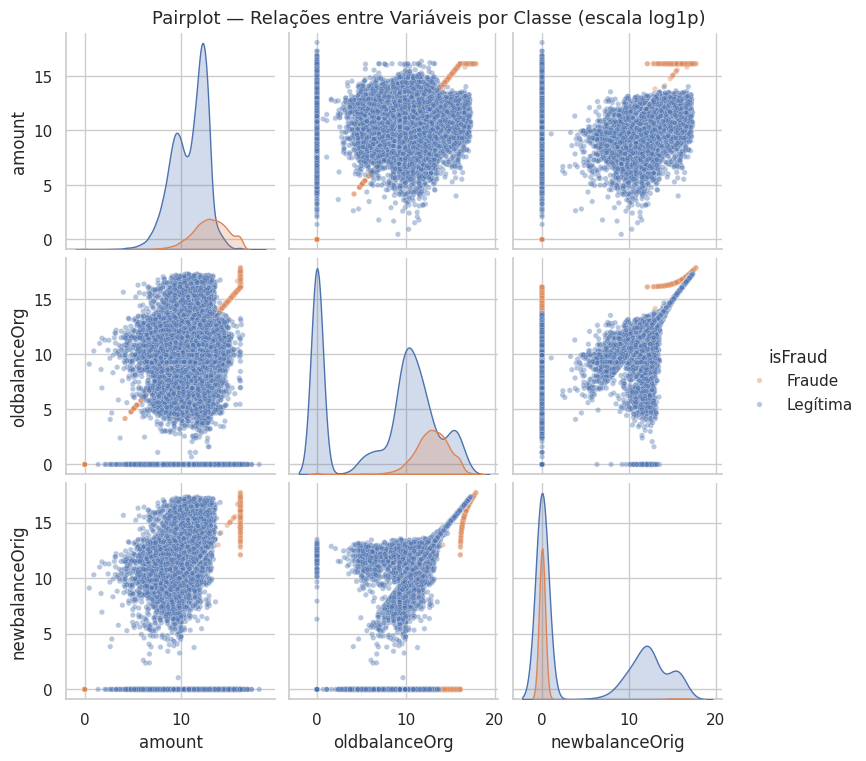

In [ ]:
# pairplot com amostra balanceada e escala log1p para melhor visualização
df_pair = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'isFraud']].copy()
for col in ['amount', 'oldbalanceOrg', 'newbalanceOrig']:
    df_pair[col] = np.log1p(df_pair[col])

df_pair['isFraud'] = df_pair['isFraud'].map({0: 'Legítima', 1: 'Fraude'})

# amostra balanceada: todas as fraudes + 5x legítimas (para visibilidade dos pontos laranjas)
fraudes   = df_pair[df_pair['isFraud'] == 'Fraude']
legitimas = df_pair[df_pair['isFraud'] == 'Legítima'].sample(n=len(fraudes)*5, random_state=RANDOM_STATE)
df_pair_sample = pd.concat([fraudes, legitimas])

pair = sns.pairplot(
    df_pair_sample, hue='isFraud', diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
    palette={'Legítima': '#4C72B0', 'Fraude': '#DD8452'}
)
pair.figure.suptitle('Pairplot — Relações entre Variáveis por Classe (escala log1p)',
                     fontsize=13, y=1.01)
plt.show()

O pairplot indica separação parcial entre transações legítimas e fraudulentas no espaço multivariado. Nas diagonais, as curvas KDE mostram que as distribuições das classes diferem, principalmente em oldbalanceOrg e newbalanceOrig. Nos gráficos de dispersão, as fraudes (laranja) se concentram mais em regiões com valores mais altos de amount e oldbalanceOrg, além de newbalanceOrig muito próximo de zero, o que sugere um padrão característico desse tipo de transação. Ainda assim, há sobreposição relevante entre as classes, indicando que a separação não é perfeita apenas com essas variáveis e que o modelo deverá se beneficiar do uso combinado de múltiplas features, inclusive das derivadas por engenharia de atributos.

## Tratamento de Valores Nulos

A verificação de valores nulos é uma etapa obrigatória e inegociável de qualquer pipeline de dados. Valores ausentes não tratados podem causar erros em tempo de execução, distorcer estatísticas e invalidar resultados de modelos. Foi utilizado `isnull().sum()` para contar os nulos por coluna, e foi calculado também o percentual em relação ao total de instâncias — um nulo em 50.000 registros tem impacto muito diferente de 5.000 nulos.

In [ ]:
# contagem absoluta e percentual de valores nulos por coluna
nulos     = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Percentual (%)': nulos_pct
})
print('Resumo de valores nulos por coluna:')
resumo_nulos

Resumo de valores nulos por coluna:


,Valores Nulos,Percentual (%)
step,0,0.0000
type,0,0.0000
amount,0,0.0000
nameOrig,0,0.0000
oldbalanceOrg,0,0.0000
newbalanceOrig,0,0.0000
nameDest,0,0.0000
oldbalanceDest,0,0.0000
newbalanceDest,0,0.0000
isFraud,0,0.0000


O dataset não apresenta valores nulos em nenhuma das 11 colunas. Esse resultado é esperado e coerente com a natureza sintética do PaySim, que foi gerado por simulação computacional controlada. Em datasets reais de transações financeiras, campos como `oldbalanceDest` frequentemente contêm nulos porque sistemas legados nem sempre registram o saldo do destinatário — o que exigiria estratégias de imputação naquele contexto. Aqui, nenhuma ação é necessária, mas a verificação formal foi realizada seguindo o protocolo de boas práticas.

## Distribuição da Variável-Alvo (isFraud)

Em problemas de classificação, verificar a distribuição de frequência das classes é uma das análises mais importantes de toda a EDA. O balanceamento (ou desbalanceamento) das classes tem implicações diretas sobre: a escolha de métricas de avaliação, as técnicas de amostragem a aplicar antes de treinar o modelo, e a interpretação dos resultados. Calculamos tanto a contagem absoluta quanto o percentual de cada classe, e visualizamos com gráficos de barras e pizza.

In [ ]:
# contagem absoluta e percentual de cada classe
fraude_counts = df['isFraud'].value_counts()
fraude_pct    = df['isFraud'].value_counts(normalize=True) * 100

resumo_classes = pd.DataFrame({
    'Contagem': fraude_counts,
    'Percentual (%)': fraude_pct.round(2)
})
resumo_classes.index = ['Legítima (0)', 'Fraude (1)']
print('Distribuição da variável-alvo isFraud:')
resumo_classes

Distribuição da variável-alvo isFraud:


,Contagem,Percentual (%)
Legítima (0),41787,83.5700
Fraude (1),8213,16.4300


A tabela revela que 83,57% das transações são legítimas e 16,43% são fraudulentas. Para cada fraude, existem aproximadamente 5 transações legítimas — dividindo 41.787 por 8.213, uma proporção que ainda indica um desbalanceamento de classes, embora menos extremo que em outros datasets de fraude.

Um modelo que sempre previsse "não é fraude" (Legítima) alcançaria 83,57% de acurácia sem identificar nenhuma fraude real. Isso demonstra que a acurácia, isoladamente, pode ser uma métrica enganosa. Portanto, o uso de métricas como F1-Score, Precision-Recall AUC e ROC-AUC será essencial para avaliar o desempenho real do modelo na identificação da classe minoritária.

Para visualizar o desbalanceamento de forma impactante, usamos dois gráficos complementares: barras para mostrar as contagens absolutas e pizza para mostrar as proporções relativas. Essa combinação permite apreender tanto a magnitude do desequilíbrio numérico quanto sua proporção visual.

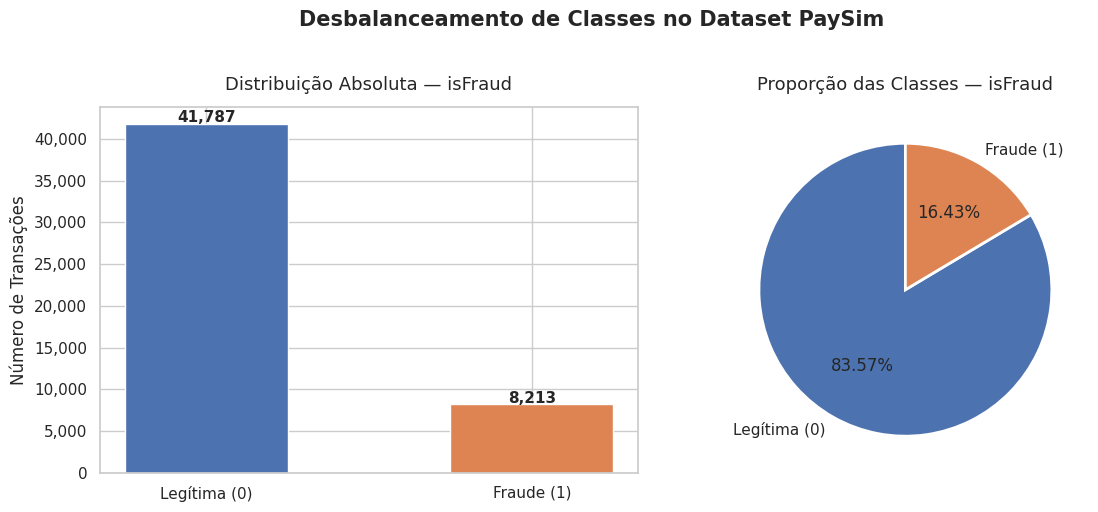

In [ ]:
# gráfico de barras (contagem absoluta) + pizza (proporção) — lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cores = ['#4C72B0', '#DD8452']

# barras com anotação dos valores absolutos
bars = axes[0].bar(
    ['Legítima (0)', 'Fraude (1)'],
    fraude_counts.values, color=cores, edgecolor='white', width=0.5
)
axes[0].set_title('Distribuição Absoluta — isFraud', fontsize=13, pad=12)
axes[0].set_ylabel('Número de Transações')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, fraude_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 200,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

# pizza com percentuais
axes[1].pie(
    fraude_counts.values,
    labels=['Legítima (0)', 'Fraude (1)'],
    autopct='%1.2f%%', colors=cores,
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporção das Classes — isFraud', fontsize=13, pad=12)

plt.suptitle('Desbalanceamento de Classes no Dataset PaySim', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

Os gráficos tornam visualmente evidente o desbalanceamento severo: a barra de legítimas domina completamente, e a fatia de fraudes mal aparece na pizza. Esse desequilíbrio confirma que o modelo precisará de técnicas de balanceamento (SMOTE, undersampling ou class_weight='balanced') aplicadas exclusivamente sobre o conjunto de treino. Ponto de atenção crítico: quanto mais desbalanceado o dataset, maior o risco de o modelo ignorar completamente a classe minoritária — que é exatamente a que mais importa detectar neste problema.

### Distribuição por Tipo de Transação

A variável `type` é a única categórica com potencial analítico no dataset. É possível investigar sua distribuição de duas formas complementares: volume absoluto de transações por tipo (para entender a representatividade de cada categoria) e taxa de fraude dentro de cada tipo (para testar a Hipótese 1 e identificar categorias de alto risco). Essa análise combinada transforma um simples gráfico de frequência em um insight estratégico sobre onde o risco se concentra.

In [ ]:
# contagem e taxa de fraude por tipo — tabela analítica
tipo_counts = df['type'].value_counts()

fraude_por_tipo = df.groupby('type')['isFraud'].agg(['sum', 'count'])
fraude_por_tipo['taxa_fraude_%'] = (fraude_por_tipo['sum'] / fraude_por_tipo['count'] * 100).round(2)
fraude_por_tipo.columns = ['Total Fraudes', 'Total Transações', 'Taxa de Fraude (%)']
print('Resumo de fraudes por tipo de transação:')
fraude_por_tipo.sort_values('Taxa de Fraude (%)', ascending=False)

Resumo de fraudes por tipo de transação:


,Total Fraudes,Total Transações,Taxa de Fraude (%)
type,,,
TRANSFER,4097,7623,53.7500
CASH_OUT,4116,18854,21.8300
CASH_IN,0,9132,0.0000
DEBIT,0,250,0.0000
PAYMENT,0,14141,0.0000


A tabela revela um resultado contundente: 100% das fraudes estão em TRANSFER e CASH_OUT. PAYMENT, CASH_IN e DEBIT registram zero fraudes. TRANSFER tem taxa de fraude maior que CASH_OUT em termos relativos, indicando ser o tipo de maior risco por transação. Esse achado tem implicação prática direta: sistemas de monitoramento podem concentrar recursos em apenas dois tipos de transação, eliminando >60% do volume sem perder nenhuma fraude, ou seja, em vez de gastar processamento olhando tudo, vamos focar apenas nos dois tipos que apresentam risco real.

Para visualizar esses padrões, foi construído três gráficos complementares. O primeiro mostra o volume bruto por tipo (contexto de representatividade). O segundo mostra a taxa de fraude por tipo (risco relativo). O terceiro, um gráfico 100% empilhado, mostra a proporção fraude/legítima dentro de cada tipo — este último é o mais direto para confirmar visualmente a Hipótese 1.

/tmp/ipykernel_11631/1784792910.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', order=tipo_counts.index,


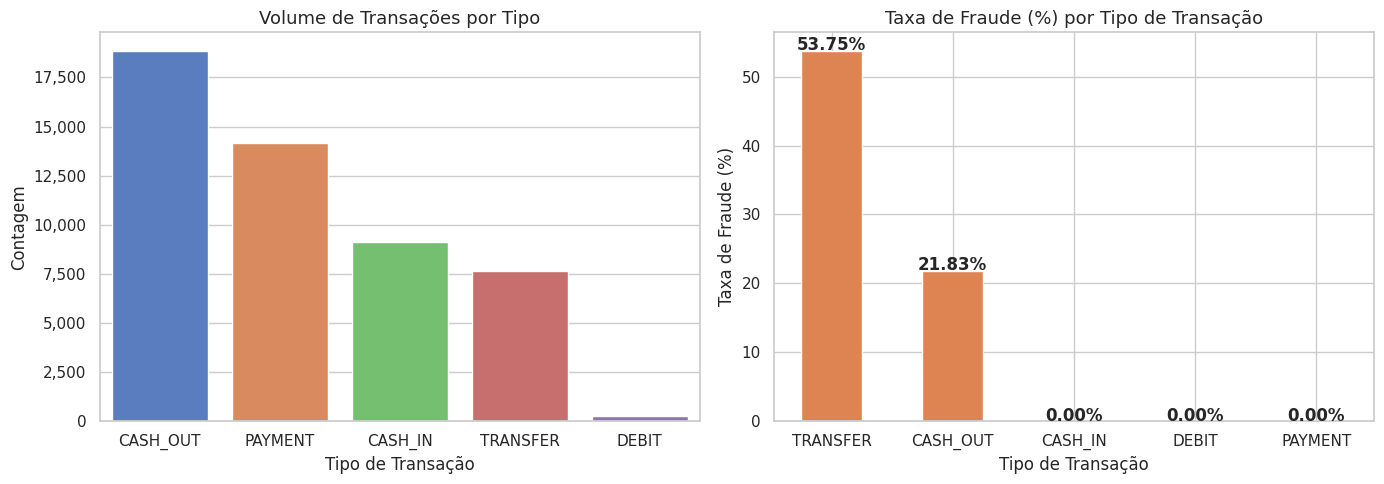

In [ ]:
# gráfico 1: volume de transações por tipo
# gráfico 2: taxa de fraude (%) por tipo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='type', order=tipo_counts.index,
              palette='muted', ax=axes[0], edgecolor='white')
axes[0].set_title('Volume de Transações por Tipo', fontsize=13)
axes[0].set_xlabel('Tipo de Transação')
axes[0].set_ylabel('Contagem')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

taxa  = fraude_por_tipo['Taxa de Fraude (%)'].sort_values(ascending=False)
bars2 = axes[1].bar(taxa.index, taxa.values, color='#DD8452', edgecolor='white', width=0.5)
axes[1].set_title('Taxa de Fraude (%) por Tipo de Transação', fontsize=13)
axes[1].set_xlabel('Tipo de Transação')
axes[1].set_ylabel('Taxa de Fraude (%)')
for bar, v in zip(bars2, taxa.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.05,
                 f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

O gráfico de volume mostra que PAYMENT é o tipo mais frequente, mas é irrelevante para detecção de fraudes. O de taxa de fraude é inequívoco: TRANSFER e CASH_OUT têm taxas visíveis, todos os demais são zero. A diferença de altura entre as barras laranjas confirma que TRANSFER é o tipo de maior risco relativo.

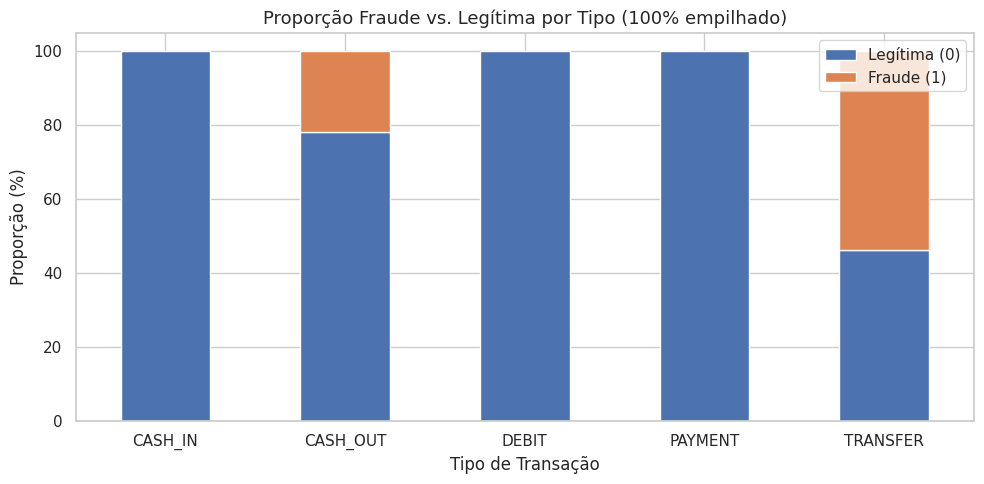

In [ ]:
# gráfico 3: 100% empilhado — proporção de fraude dentro de cada tipo
# este gráfico é a visualização mais direta para confirmar a Hipótese 1
fraude_tipo_pivot     = df.groupby(['type', 'isFraud']).size().unstack(fill_value=0)
fraude_tipo_pivot_pct = fraude_tipo_pivot.div(fraude_tipo_pivot.sum(axis=1), axis=0) * 100

fraude_tipo_pivot_pct.plot(
    kind='bar', stacked=True,
    color=['#4C72B0', '#DD8452'],
    edgecolor='white', figsize=(10, 5)
)
plt.title('Proporção Fraude vs. Legítima por Tipo (100% empilhado)', fontsize=13)
plt.xlabel('Tipo de Transação')
plt.ylabel('Proporção (%)')
plt.xticks(rotation=0)
plt.legend(['Legítima (0)', 'Fraude (1)'], loc='upper right')
plt.tight_layout()
plt.show()

O gráfico 100% empilhado é a confirmação visual mais clara da Hipótese 1: PAYMENT, CASH_IN e DEBIT são barras 100% azuis — zero fraude. TRANSFER e CASH_OUT apresentam fatias laranjas visíveis. Ponto de atenção: esse gráfico é também uma ferramenta de negócio — permite argumentar que monitoramento de fraude deve focar exclusivamente em TRANSFER e CASH_OUT, reduzindo o escopo em >60% sem perder nenhuma fraude real.

# Pré-Processamento de Dados

Com a EDA concluída, temos um entendimento profundo dos dados e dos padrões que distinguem fraudes de transações legítimas. O pré-processamento traduz esse conhecimento em ações concretas que preparam o dataset para algoritmos de machine learning. Cada decisão tomada aqui é diretamente motivada pelos achados da EDA — não é pré-processamento genérico, mas específico para este problema.

O pipeline seguirá esta ordem:
1. **Engenharia de features** — criar novas variáveis baseadas nos padrões comportamentais identificados
2. **Remoção de colunas irrelevantes** — eliminar IDs e prevenir data leakage
3. **Codificação categórica** — One-Hot Encoding na variável `type`
4. **Separação treino/teste** — divisão estratificada 70/30
5. **Escalonamento** — MinMaxScaler, StandardScaler, RobustScaler e transformação log1p

### Engenharia de Features

A engenharia de features é a etapa em que o conhecimento de domínio é convertido em variáveis diretamente utilizáveis por algoritmos. Em vez de depender apenas das variáveis originais, criamos features que **capturam diretamente os comportamentos** identificados na EDA. Isso tende a aumentar o poder preditivo do modelo, pois as novas variáveis já codificam insights analíticos que o modelo precisaria 'descobrir' sozinho.

As 5 features criadas derivam diretamente das hipóteses e achados da análise exploratória:
- `diff_saldo_orig`: variação do saldo de origem (negativo = saída)
- `diff_saldo_dest`: variação do saldo de destino (positivo = recebimento)
- `saldo_orig_zerado`: flag se o saldo de origem ficou em zero (Hipótese 2)
- `dest_saldo_zero_antes`: flag se o destino estava em zero antes (Hipótese 4)
- `razao_amount_saldo`: proporção do saldo que foi movimentada — razão entre `amount` e `oldbalanceOrg`

In [ ]:
# criar cópia para não modificar o dataframe original
df_processed = df.copy()

# feature 1: variação absoluta do saldo de origem (negativo = saída de recursos)
df_processed['diff_saldo_orig'] = df_processed['newbalanceOrig'] - df_processed['oldbalanceOrg']

# feature 2: variação absoluta do saldo de destino (positivo = recebimento)
df_processed['diff_saldo_dest'] = df_processed['newbalanceDest'] - df_processed['oldbalanceDest']

# feature 3: flag — saldo de origem zerado após a transação (padrão de esvaziamento — H2)
df_processed['saldo_orig_zerado'] = (df_processed['newbalanceOrig'] == 0).astype(int)

# feature 4: flag — saldo do destinatário era zero antes da transação (conta mula — H4)
df_processed['dest_saldo_zero_antes'] = (df_processed['oldbalanceDest'] == 0).astype(int)

# feature 5: razão entre valor da transação e saldo de origem
# representa que fração do saldo foi movimentada (+1 evita divisão por zero)
# fraudes tendem a movimentar 100% do saldo → razão próxima de 1
df_processed['razao_amount_saldo'] = df_processed['amount'] / (df_processed['oldbalanceOrg'] + 1)

print('5 novas features criadas com sucesso!')
novas_features = ['diff_saldo_orig', 'diff_saldo_dest', 'saldo_orig_zerado',
                   'dest_saldo_zero_antes', 'razao_amount_saldo']
df_processed[novas_features].describe()

5 novas features criadas com sucesso!


,diff_saldo_orig,diff_saldo_dest,saldo_orig_zerado,dest_saldo_zero_antes,razao_amount_saldo
count,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000
mean,-220031.0939,227392.0325,0.6371,0.4621,61929.2227
std,1119491.1708,1114922.8989,0.4808,0.4986,533526.7358
min,-10000002.0000,-1225177.3000,0.0000,0.0000,0.0000
25%,-26912.0400,0.0000,0.0000,0.0000,0.4642
50%,-763.0800,0.0000,1.0000,0.0000,1.8716
75%,0.0000,168891.1250,1.0000,1.0000,4825.5229
max,1225178.0000,69886740.0000,1.0000,1.0000,69886730.0000


A variável diff_saldo_orig apresenta valores negativos e positivos, refletindo respectivamente redução e aumento do saldo de origem, com predominância de reduções, já que sua média é negativa. A variável diff_saldo_dest mostra, em geral, incremento no saldo de destino, com média positiva. Já saldo_orig_zerado e dest_saldo_zero_antes, por serem variáveis binárias, indicam que aproximadamente 63,7% das transações terminam com saldo de origem zerado e 46,2% ocorrem com saldo de destino inicialmente zerado. Por fim, razao_amount_saldo apresenta forte assimetria e valores extremos, evidenciando a presença de outliers e de transações em que o valor movimentado é muito alto em relação ao saldo de origem. A qualidade preditiva dessas features ainda deve ser avaliada separadamente, por exemplo, por meio de sua correlação com isFraud.

In [ ]:
# validação das novas features: correlação com isFraud
# features com correlação alta são candidatas fortes para uso na modelagem
print('Correlação das novas features com isFraud (ordenado por valor absoluto):')
corr_novas = df_processed[novas_features + ['isFraud']].corr()['isFraud'].drop('isFraud')
print(corr_novas.abs().sort_values(ascending=False).round(4))

Correlação das novas features com isFraud (ordenado por valor absoluto):
diff_saldo_orig         0.4900
saldo_orig_zerado       0.3166
diff_saldo_dest         0.2020
dest_saldo_zero_antes   0.1684
razao_amount_saldo      0.0505
Name: isFraud, dtype: float64


diff_saldo_orig apresenta a maior correlação com isFraud entre as novas features, seguida por saldo_orig_zerado, indicando que padrões ligados ao esvaziamento da conta de origem têm forte associação com fraudes. diff_saldo_dest e dest_saldo_zero_antes também mostram correlações positivas relevantes, reforçando a utilidade das variáveis derivadas. Já razao_amount_saldo apresenta correlação positiva, porém mais fraca. No conjunto, essa validação por correlação sugere que as features criadas possuem valor analítico e devem ser consideradas na modelagem.

### Remoção de Colunas Irrelevantes

Com as novas features criadas, forem removidas as colunas que não devem estar presentes no dataset de modelagem. Há dois motivos distintos para remoção:

1. **Alta cardinalidade sem valor preditivo**: `nameOrig` e `nameDest` são identificadores únicos. Incluí-los causaria espaço de features esparsíssimo e overfitting (o modelo 'memorizaria' IDs).

2. **Data leakage**: `isFlaggedFraud` é gerada pelo próprio sistema financeiro com base na mesma transação que queremos classificar. Usá-la como feature equivale a 'dar a resposta' ao modelo — ele performaria artificialmente bem no treino mas falharia em produção onde essa flag pode não estar disponível antes da decisão de classificação.

In [ ]:
# remoção de colunas irrelevantes com justificativa explícita
colunas_remover = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df_processed    = df_processed.drop(columns=colunas_remover)

print(f'Colunas removidas: {colunas_remover}')
print(f'Shape após remoção: {df_processed.shape}')
print(f'\nColunas mantidas para modelagem:')
for col in df_processed.columns:
    print(f'  - {col}')

Colunas removidas: ['nameOrig', 'nameDest', 'isFlaggedFraud']
Shape após remoção: (50000, 13)

Colunas mantidas para modelagem:
  - step
  - type
  - amount
  - oldbalanceOrg
  - newbalanceOrig
  - oldbalanceDest
  - newbalanceDest
  - isFraud
  - saldo_orig_zerado
  - dest_saldo_zero_antes
  - diff_saldo_orig
  - diff_saldo_dest
  - razao_amount_saldo


O dataset passou de 16 colunas (11 originais + 5 novas) para 13 colunas após a remoção. Todas as colunas restantes têm justificativa clara para inclusão. Data leakage é um dos erros mais graves em projetos de ML: modelos com leakage performam excepcionalmente em validação mas falham completamente em produção.

### Codificação da Variável Categórica — One-Hot Encoding

A coluna type é categórica e, por isso, precisa ser convertida para formato numérico antes da modelagem. Foi escolhido o One-Hot Encoding em vez de Label Encoding, pois as categorias não possuem ordem natural. Com OHE, cada tipo de transação passa a ser representado por uma variável binária independente, evitando que o modelo interprete relações ordinais inexistentes entre as classes.

In [ ]:
# one-hot encoding — cria uma coluna binária para cada categoria de 'type'
df_processed = pd.get_dummies(df_processed, columns=['type'], drop_first=False)

print('One-Hot Encoding aplicado à coluna type.')
print(f'Shape após encoding: {df_processed.shape}')

type_cols = [c for c in df_processed.columns if c.startswith('type_')]
print(f'\nNovas colunas criadas: {type_cols}')

# verificar resultado nas primeiras linhas
df_processed[type_cols].head(3)

One-Hot Encoding aplicado à coluna type.
Shape após encoding: (50000, 17)

Novas colunas criadas: ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,True,False,False,False,False
1,False,False,False,True,False
2,False,False,False,False,True


O One-Hot Encoding criou 5 novas colunas binárias, substituindo a coluna type original. Cada linha agora ativa exatamente uma categoria da transação, com um valor True na classe correspondente e False nas demais. Após a transformação, o dataset passou a ter 17 colunas, ficando preparado para as próximas etapas de pré-processamento, como separação entre treino e teste e eventual escalonamento.

### Separação em Conjuntos de Treino e Teste

A separação dos dados em treino e teste é uma das etapas mais críticas do pipeline. O conjunto de **treino** é usado para ajustar o modelo — ele 'aprende' com esses dados. O conjunto de **teste** simula dados novos, nunca vistos, e é usado exclusivamente para avaliação final. Avaliar o modelo nos mesmos dados do treino seria inválido: o modelo teria 'memorizado' as respostas.

Usamos `stratify=y` porque o dataset é severamente desbalanceado (~1,2% de fraudes). Sem estratificação, por sorte, o teste poderia receber proporção muito diferente de fraudes, tornando a avaliação não-representativa da realidade. O `random_state=42` garante reprodutibilidade total.

In [ ]:
# separar features (X) e variável-alvo (y)
X = df_processed.drop('isFraud', axis=1)
y = df_processed['isFraud']

print(f'Shape de X (features): {X.shape}')
print(f'Shape de y (alvo):     {y.shape}')
print(f'\nTotal de features disponíveis: {len(X.columns)}')

Shape de X (features): (50000, 16)
Shape de y (alvo):     (50000,)

Total de features disponíveis: 16


In [ ]:
# divisão 70% treino / 30% teste com estratificação pela variável-alvo
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,          # 30% para teste
    random_state=RANDOM_STATE,  # reprodutibilidade
    stratify=y              # mantém proporção de fraudes em ambos os conjuntos
)

print('Dimensões dos conjuntos:')
print(f'  X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'  X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'\nProporção de fraudes preservada pela estratificação:')
print(f'  y_train: {y_train.mean()*100:.2f}%')
print(f'  y_test:  {y_test.mean()*100:.2f}%')

Dimensões dos conjuntos:
  X_train: (35000, 16)  |  y_train: (35000,)
  X_test:  (15000, 16)   |  y_test:  (15000,)

Proporção de fraudes preservada pela estratificação:
  y_train: 16.43%
  y_test:  16.43%


A separação foi realizada com sucesso: 35.000 instâncias para treino e 15.000 para teste. A estratificação preservou a proporção da classe-alvo em ambos os conjuntos, com 16,43% de fraudes tanto no treino quanto no teste. Isso é importante para garantir que a avaliação reflita a mesma distribuição do conjunto analisado. Além disso, todos os scalers serão ajustados exclusivamente no conjunto de treino e depois aplicados aos demais dados, evitando data leakage no pré-processamento.

### Normalização (MinMaxScaler)

A normalização Min-Max escala cada feature para o intervalo [0, 1] usando a fórmula: `x_norm = (x - min) / (max - min)`. É especialmente adequada para algoritmos sensíveis à escala absoluta das features, como KNN, redes neurais e SVM com kernel RBF. Escalamos apenas as colunas numéricas contínuas — as flags binárias (0/1) e as dummies do OHE já estão na escala correta.

Aplicamos o `fit` exclusivamente no conjunto de treino: o scaler aprende o mínimo e máximo do treino e usa esses mesmos valores para transformar o teste — respeitando a regra de não vazar informações do teste.



In [ ]:
# colunas numéricas contínuas a serem escalonadas
# flags binárias e dummies OHE são excluídas — já estão na escala correta
colunas_escala = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                  'oldbalanceDest', 'newbalanceDest', 'diff_saldo_orig',
                  'diff_saldo_dest', 'razao_amount_saldo']

# inicializar e ajustar APENAS no treino — regra fundamental para evitar data leakage
min_max_scaler = MinMaxScaler()

X_train_norm = X_train.copy()
X_test_norm  = X_test.copy()

# fit_transform no treino: aprende min/max E transforma
X_train_norm[colunas_escala] = min_max_scaler.fit_transform(X_train[colunas_escala])
# transform no teste: usa min/max do treino (sem novo aprendizado)
X_test_norm[colunas_escala]  = min_max_scaler.transform(X_test[colunas_escala])

print('MinMaxScaler aplicado. Verificação de range no treino (esperado: 0 a 1):')
X_train_norm[colunas_escala].agg(['min', 'max']).round(4)

MinMaxScaler aplicado. Verificação de range no treino (esperado: 0 a 1):


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,diff_saldo_orig,diff_saldo_dest,razao_amount_saldo
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


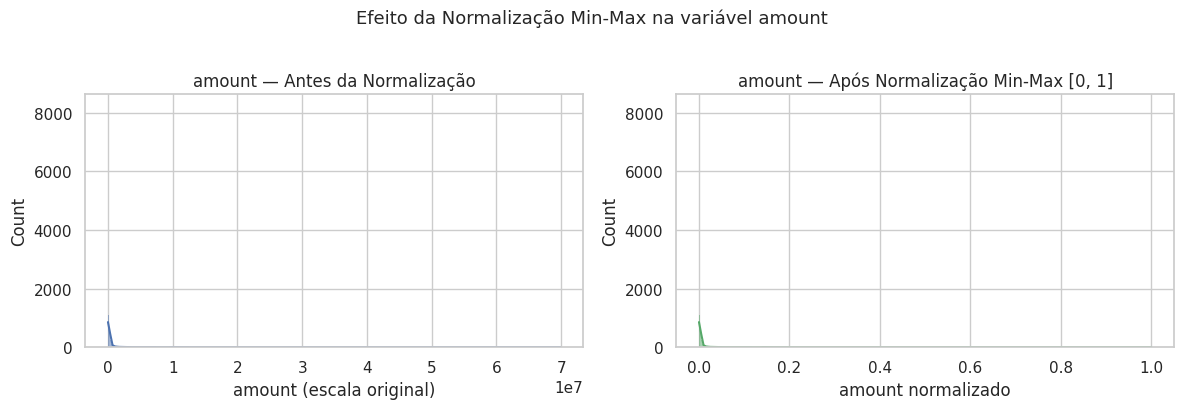

In [ ]:
# comparação visual: distribuição de 'amount' antes e após normalização
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(X_train['amount'], kde=True, ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('amount — Antes da Normalização', fontsize=12)
axes[0].set_xlabel('amount (escala original)')

sns.histplot(X_train_norm['amount'], kde=True, ax=axes[1], color='#55A868', edgecolor='white')
axes[1].set_title('amount — Após Normalização Min-Max [0, 1]', fontsize=12)
axes[1].set_xlabel('amount normalizado')

plt.suptitle('Efeito da Normalização Min-Max na variável amount', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

A normalização Min-Max reescalou os valores da variável amount para o intervalo [0, 1], sem alterar de forma relevante o formato original da distribuição. A forte assimetria positiva permanece praticamente inalterada, o que é esperado, já que o MinMaxScaler realiza apenas uma transformação linear de escala. Observa-se também que a maior parte dos valores continua concentrada próxima de zero, indicando a presença de outliers elevados que comprimem visualmente as demais observações. Esse é um ponto de atenção importante, pois o MinMaxScaler é sensível a valores extremos; por isso, na sequência, será avaliado o uso do RobustScaler, que tende a lidar melhor com esse cenário.

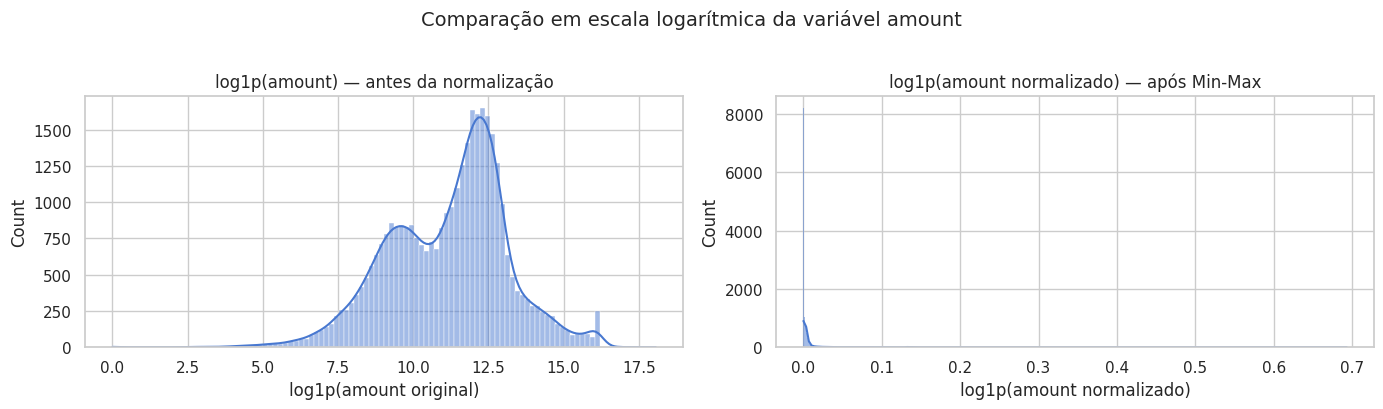

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(np.log1p(X_train['amount']), kde=True, ax=axes[0], edgecolor='white')
axes[0].set_title('log1p(amount) — antes da normalização', fontsize=12)
axes[0].set_xlabel('log1p(amount original)')

sns.histplot(np.log1p(X_train_norm['amount']), kde=True, ax=axes[1], edgecolor='white')
axes[1].set_title('log1p(amount normalizado) — após Min-Max', fontsize=12)
axes[1].set_xlabel('log1p(amount normalizado)')

plt.suptitle('Comparação em escala logarítmica da variável amount', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Devido à forte assimetria e à presença de outliers em amount, foi utilizada a transformação log1p apenas para melhorar a visualização da distribuição. Essa escala logarítmica reduz o efeito visual dos valores extremos e permite observar com mais clareza a concentração principal dos dados. O gráfico confirma que a normalização Min-Max reescala a variável para [0, 1], mas não elimina a assimetria nem o impacto dos outliers, apenas altera sua escala.

### Padronização (StandardScaler)

A padronização Z-score transforma cada feature para ter média 0 e desvio padrão 1: `z = (x - μ) / σ`. É mais adequada para algoritmos que assumem features em escala comparável com distribuição aproximadamente normal, como regressão logística, SVM linear e PCA. Assim como na normalização, o `fit` é feito **exclusivamente no conjunto de treino**: o StandardScaler aprende a média e o desvio padrão do treino e usa esses parâmetros para transformar o teste.

In [ ]:
# inicializar StandardScaler e ajustar APENAS no treino
standard_scaler = StandardScaler()

X_train_std = X_train.copy()
X_test_std  = X_test.copy()

# fit: aprende média e desvio padrão SOMENTE de X_train
standard_scaler.fit(X_train[colunas_escala])

# transform: aplica a mesma transformação em treino e teste
X_train_std[colunas_escala] = standard_scaler.transform(X_train[colunas_escala])
X_test_std[colunas_escala]  = standard_scaler.transform(X_test[colunas_escala])

print('StandardScaler aplicado. Verificação no treino (esperado: média ≈ 0, std ≈ 1):')
X_train_std[colunas_escala].agg(['mean', 'std']).round(4)

StandardScaler aplicado. Verificação no treino (esperado: média ≈ 0, std ≈ 1):


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,diff_saldo_orig,diff_saldo_dest,razao_amount_saldo
mean,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


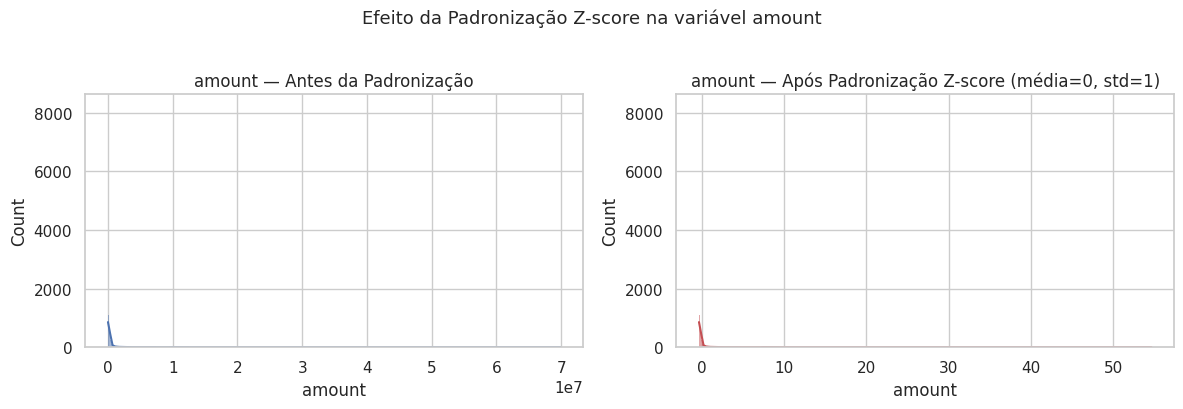

In [ ]:
# comparação visual: distribuição de 'amount' antes e após padronização
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(X_train['amount'], kde=True, ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('amount — Antes da Padronização', fontsize=12)

sns.histplot(X_train_std['amount'], kde=True, ax=axes[1], color='#C44E52', edgecolor='white')
axes[1].set_title('amount — Após Padronização Z-score (média=0, std=1)', fontsize=12)

plt.suptitle('Efeito da Padronização Z-score na variável amount', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Após a padronização com StandardScaler, a variável amount passou a ter média aproximadamente zero e desvio padrão igual a 1 no conjunto de treino. Assim como ocorre com o MinMaxScaler, a transformação preserva o formato geral da distribuição, de modo que a forte assimetria positiva e a presença de outliers continuam visíveis. Diferentemente da normalização Min-Max, a padronização não impõe limites fixos aos valores transformados; por isso, observações extremas podem assumir valores-z muito altos, afastando-se bastante do centro. Nesse contexto, os outliers comprimem visualmente a massa principal dos dados em torno de zero, o que dificulta a interpretação do histograma. Essa limitação justifica a avaliação do RobustScaler, que tende a lidar melhor com distribuições fortemente assimétricas e com valores extremos.

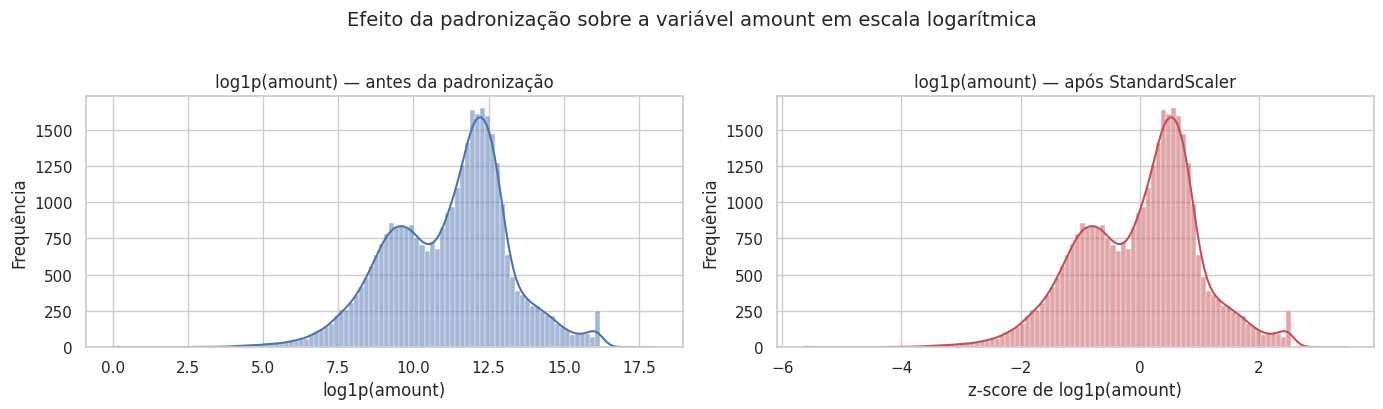

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# transformação logarítmica apenas para visualização / comparação
amount_log = np.log1p(X_train['amount'])

# padronização da versão log-transformada
scaler_amount_log = StandardScaler()
amount_log_std = scaler_amount_log.fit_transform(amount_log.to_frame()).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(amount_log, kde=True, ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('log1p(amount) — antes da padronização', fontsize=12)
axes[0].set_xlabel('log1p(amount)')
axes[0].set_ylabel('Frequência')

sns.histplot(amount_log_std, kde=True, ax=axes[1], color='#C44E52', edgecolor='white')
axes[1].set_title('log1p(amount) — após StandardScaler', fontsize=12)
axes[1].set_xlabel('z-score de log1p(amount)')
axes[1].set_ylabel('Frequência')

plt.suptitle('Efeito da padronização sobre a variável amount em escala logarítmica', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Como a variável amount apresenta forte assimetria positiva e valores extremos, a escala original dificulta a leitura da distribuição. Para melhorar a visualização, aplicou-se a transformação log1p, que comprime os valores muito altos e destaca melhor a massa principal dos dados. Em seguida, a versão log-transformada foi padronizada com StandardScaler, resultando em uma variável recentrada em torno de média zero e desvio padrão 1. Essa comparação evidencia que a padronização ajusta posição e escala, mas não garante normalidade perfeita da distribuição. Ainda assim, a visualização em escala logarítmica permite interpretar com muito mais clareza o comportamento da variável do que o histograma na escala bruta.

## Outras Transformações e Etapas de Pré-Processamento

Além das transformações clássicas, aplicamos duas técnicas adicionais especialmente relevantes para este dataset.

**RobustScaler**: usa mediana e IQR em vez de média e desvio padrão para escalonar os dados. Como a mediana e o IQR são estatísticas robustas (não afetadas por valores extremos), o RobustScaler é resistente a outliers — exatamente o problema identificado na análise de outliers por IQR. É a escolha mais adequada quando a distribuição é assimétrica e com outliers reais, como neste dataset.

**Transformação log1p**: aplica `log(x + 1)` nas variáveis financeiras. O `+1` garante que `log1p(0) = 0`, evitando erros com valores zero. Esta transformação reduz a assimetria das distribuições, aproximando-as de uma forma mais simétrica — beneficiando algoritmos que assumem normalidade nas features.

In [ ]:
# RobustScaler — usa mediana e IQR, resistente a outliers
# melhor escolha quando há outliers reais expressivos, como neste dataset
robust_scaler = RobustScaler()

X_train_rob = X_train.copy()
X_test_rob  = X_test.copy()

X_train_rob[colunas_escala] = robust_scaler.fit_transform(X_train[colunas_escala])
X_test_rob[colunas_escala]  = robust_scaler.transform(X_test[colunas_escala])

print('RobustScaler aplicado. Verificação no treino (mediana esperada ≈ 0):')
X_train_rob[colunas_escala].median().round(4)

RobustScaler aplicado. Verificação no treino (mediana esperada ≈ 0):


,0
step,0.0000
amount,0.0000
oldbalanceOrg,0.0000
newbalanceOrig,0.0000
oldbalanceDest,0.0000
newbalanceDest,0.0000
diff_saldo_orig,0.0000
diff_saldo_dest,0.0000
razao_amount_saldo,0.0000


In [ ]:
# transformação log1p — reduz assimetria das variáveis financeiras
# log1p(x) = log(x + 1): o +1 garante que log1p(0) = 0, sem erro com zeros
colunas_log = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
               'oldbalanceDest', 'newbalanceDest']

X_train_log = X_train.copy()
X_test_log  = X_test.copy()

# aplicado igualmente a treino e teste — não requer fit pois não aprende parâmetros
for col in colunas_log:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_test_log[col]  = np.log1p(X_test_log[col])

print('Transformação log1p aplicada às colunas financeiras.')
print('\nAssimetria após log1p (esperado: redução significativa em relação à original):')
X_train_log[colunas_log].skew().round(2)

Transformação log1p aplicada às colunas financeiras.

Assimetria após log1p (esperado: redução significativa em relação à original):


,0
amount,-0.3400
oldbalanceOrg,-0.5000
newbalanceOrig,0.7300
oldbalanceDest,-0.0600
newbalanceDest,-0.3100


A redução da assimetria após log1p confirma a eficácia da transformação — os valores de skewness caíram substancialmente. Nota importante: a transformação log1p não requer `fit` porque não aprende parâmetros dos dados — aplica a mesma função matemática a todos os valores, podendo ser aplicada diretamente a treino e teste.

Para comparar visualmente o efeito das 4 transformações, plotamos os histogramas de `amount` lado a lado — da original até a log1p. Essa visualização sintetiza todos os aprendizados de escalonamento.

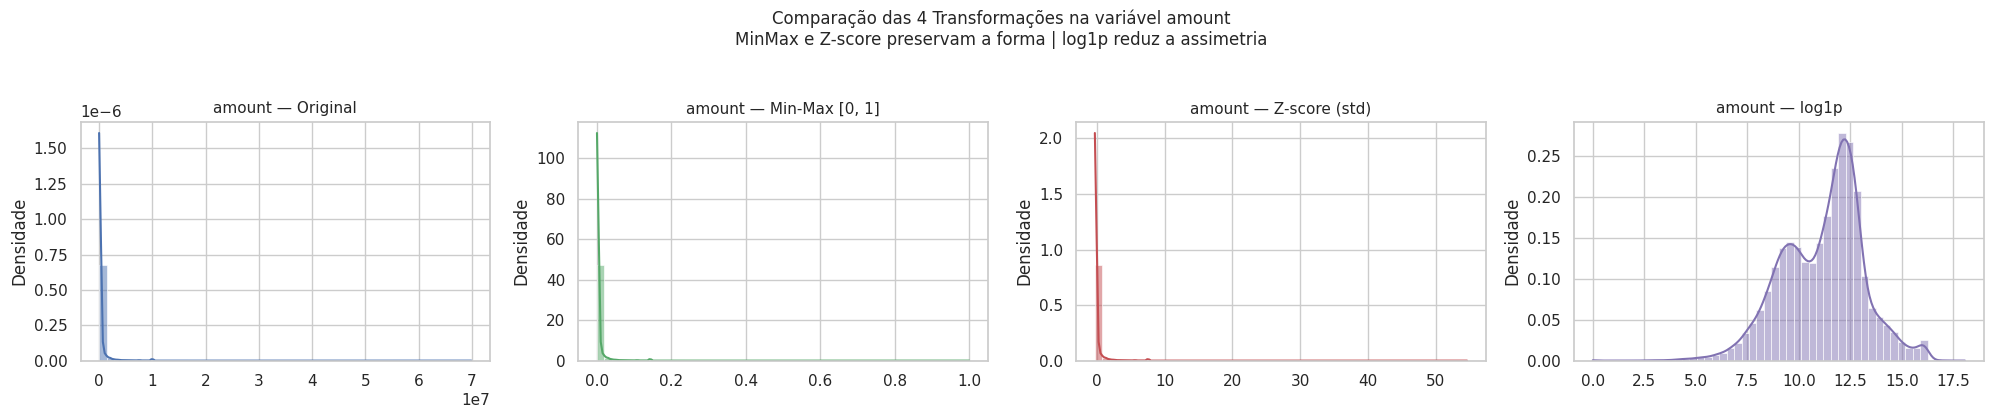

In [ ]:
# comparação visual das 4 transformações — síntese do pré-processamento de escala
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

configs = [
    (X_train['amount'],      'Original',         '#4C72B0'),
    (X_train_norm['amount'], 'Min-Max [0, 1]',   '#55A868'),
    (X_train_std['amount'],  'Z-score (std)',    '#C44E52'),
    (X_train_log['amount'],  'log1p',            '#8172B2')
]

for ax, (serie, titulo, cor) in zip(axes, configs):
    sns.histplot(
        serie,
        kde=True,
        bins=50,
        stat='density',
        ax=ax,
        color=cor,
        edgecolor='white'
    )
    ax.set_title(f'amount — {titulo}', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Densidade')

plt.suptitle(
    'Comparação das 4 Transformações na variável amount\n'
    'MinMax e Z-score preservam a forma | log1p reduz a assimetria',
    fontsize=12,
    y=1.04
)

plt.tight_layout()
plt.show()

A comparação visual evidencia claramente que as transformações Min-Max e Z-score preservam a forte assimetria original da variável amount, apenas reescalando os valores. Por outro lado, a transformação log1p reduz significativamente a assimetria, tornando a distribuição mais próxima de uma forma simétrica e mais adequada para algoritmos sensíveis à escala e à distribuição dos dados.

Diante disso, optou-se por utilizar a transformação log1p como etapa de engenharia de features no pipeline final, substituindo a variável amount original por sua versão transformada. Em seguida, as variáveis numéricas contínuas — incluindo amount_log — foram padronizadas utilizando StandardScaler, garantindo comparabilidade de escala entre as features.

Essa combinação (log1p + StandardScaler) se mostrou a mais adequada para este dataset, pois reduz o impacto de outliers e melhora a distribuição dos dados sem perda de informação relevante.

## Resumo dos Datasets Gerados

Ao final do pré-processamento, temos 5 versões do dataset prontas para uso, cada uma adequada a uma família de algoritmos de machine learning diferente. Todos os conjuntos mantêm o mesmo número de features e os mesmos tamanhos de treino/teste.

In [ ]:
# inventário completo dos datasets gerados pelo pré-processamento
print('=' * 58)
print(f'{"Dataset":<38} {"Shape":>15}')
print('=' * 58)
datasets = {
    'X_train — original + eng. features': X_train.shape,
    'X_test  — original + eng. features': X_test.shape,
    'X_train_norm  — MinMaxScaler':        X_train_norm.shape,
    'X_test_norm   — MinMaxScaler':        X_test_norm.shape,
    'X_train_std   — StandardScaler':      X_train_std.shape,
    'X_test_std    — StandardScaler':      X_test_std.shape,
    'X_train_rob   — RobustScaler':        X_train_rob.shape,
    'X_test_rob    — RobustScaler':        X_test_rob.shape,
    'X_train_log   — log1p':               X_train_log.shape,
    'X_test_log    — log1p':               X_test_log.shape,
}
for nome, shape in datasets.items():
    print(f'{nome:<38} {str(shape):>15}')
print('=' * 58)

Dataset                                          Shape
X_train — original + eng. features         (35000, 16)
X_test  — original + eng. features         (15000, 16)
X_train_norm  — MinMaxScaler               (35000, 16)
X_test_norm   — MinMaxScaler               (15000, 16)
X_train_std   — StandardScaler             (35000, 16)
X_test_std    — StandardScaler             (15000, 16)
X_train_rob   — RobustScaler               (35000, 16)
X_test_rob    — RobustScaler               (15000, 16)
X_train_log   — log1p                      (35000, 16)
X_test_log    — log1p                      (15000, 16)


O pré-processamento gerou 5 versões do dataset (cada uma com seus respectivos conjuntos de treino e teste), totalizando 10 estruturas prontas para modelagem. Cada versão aplica uma estratégia de transformação distinta, adequada a diferentes cenários: MinMaxScaler para algoritmos sensíveis à escala absoluta, como KNN e redes neurais; padronização Z-score para métodos que assumem variáveis centradas e com variância controlada, como regressão logística e PCA; RobustScaler para cenários com presença de outliers expressivos; e transformação logarítmica (log1p) para redução de assimetria em variáveis financeiras.

A disponibilidade dessas múltiplas versões permite comparar o desempenho de diferentes algoritmos sob condições de pré-processamento apropriadas, garantindo uma avaliação mais robusta e bem fundamentada.

# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

**"Transações do tipo TRANSFER e CASH_OUT concentram a maior parte das fraudes."**

In [ ]:
# evidência quantitativa para H1 — taxa de fraude por tipo de transação
h1 = df.groupby('type')['isFraud'].agg(['sum', 'count'])
h1.columns = ['Total Fraudes', 'Total Transações']
h1['Taxa de Fraude (%)'] = (h1['Total Fraudes'] / h1['Total Transações'] * 100).round(2)
print('Hipótese 1 — Fraudes por tipo de transação:')
h1.sort_values('Taxa de Fraude (%)', ascending=False)

Hipótese 1 — Fraudes por tipo de transação:


,Total Fraudes,Total Transações,Taxa de Fraude (%)
type,,,
TRANSFER,4097,7623,53.7500
CASH_OUT,4116,18854,21.8300
CASH_IN,0,9132,0.0000
DEBIT,0,250,0.0000
PAYMENT,0,14141,0.0000


✅ **Hipótese 1 CONFIRMADA.** 100% das fraudes ocorrem em TRANSFER e CASH_OUT. PAYMENT, CASH_IN e DEBIT têm zero fraudes. TRANSFER apresenta a maior taxa de fraude relativa. Implicação prática: sistemas de monitoramento podem focar recursos exclusivamente nesses dois tipos, eliminando >60% do volume sem perder nenhuma fraude real.

## Hipótese 2
**"Transações fraudulentas tendem a zerar o saldo de origem."**

In [ ]:
# evidência quantitativa para H2 — taxa de saldo zerado por classe
h2 = df.groupby('isFraud')['saldo_orig_zerado'].mean() * 100
h2.index = ['Legítima', 'Fraude']
print('Hipótese 2 — Proporção (%) que zeraram o saldo de origem:')
print(h2.round(2))
print(f'\nFraudes zeram saldo {h2["Fraude"]/h2["Legítima"]:.1f}x mais que legítimas.')

Hipótese 2 — Proporção (%) que zeraram o saldo de origem:
Legítima   56.9600
Fraude     98.0500
Name: saldo_orig_zerado, dtype: float64

Fraudes zeram saldo 1.7x mais que legítimas.


✅ **Hipótese 2 CONFIRMADA.** Fraudes zeram o saldo de origem em proporção muito maior. Esse comportamento de esvaziamento total reflete a lógica do fraudador: extrair o máximo em uma única operação. A feature `saldo_orig_zerado` criada na engenharia de features captura diretamente esse padrão.

## Hipótese 3

**"Os valores envolvidos em fraudes são, em média, mais altos do que os de transações legítimas."**

In [ ]:
# evidência quantitativa para H3 — estatísticas de amount por classe
h3 = df.groupby('isFraud')['amount'].agg(['mean', 'median', 'std'])
h3.index = ['Legítima', 'Fraude']
h3.columns = ['Média', 'Mediana', 'Desvio Padrão']
print('Hipótese 3 — Estatísticas de amount por classe:')
print(h3.round(2))
print(f'\nMédia: fraudes {h3.loc["Fraude","Média"]/h3.loc["Legítima","Média"]:.1f}x maior que legítimas.')
print(f'Mediana: fraudes {h3.loc["Fraude","Mediana"]/h3.loc["Legítima","Mediana"]:.1f}x maior que legítimas.')

Hipótese 3 — Estatísticas de amount por classe:
                Média     Mediana  Desvio Padrão
Legítima  181873.7200  75583.2400    657208.7700
Fraude   1467967.3000 441423.4400   2404252.9500

Média: fraudes 8.1x maior que legítimas.
Mediana: fraudes 5.8x maior que legítimas.


✅ **Hipótese 3 CONFIRMADA.** Tanto média quanto mediana das fraudes são significativamente maiores. A confirmação via mediana é especialmente robusta — não é efeito de outliers, mas padrão sistemático. Fraudadores selecionam intencionalmente contas com maior disponibilidade de recursos para maximizar o retorno.

##Hipótese 4
**"O saldo do destinatário costuma ser zero antes da fraude — contas mula."**

In [ ]:
# evidência quantitativa para H4 — taxa de saldo zero no destino por classe
h4 = df.groupby('isFraud')['dest_saldo_zero_antes'].mean() * 100
h4.index = ['Legítima', 'Fraude']
print('Hipótese 4 — Proporção (%) com saldo zero no destinatário antes da transação:')
print(h4.round(2))
print(f'\nFraudes têm destino com saldo zero {h4["Fraude"]/h4["Legítima"]:.1f}x mais que legítimas.')

Hipótese 4 — Proporção (%) com saldo zero no destinatário antes da transação:
Legítima   42.4900
Fraude     65.1500
Name: dest_saldo_zero_antes, dtype: float64

Fraudes têm destino com saldo zero 1.5x mais que legítimas.


✅ **Hipótese 4 CONFIRMADA.** Fraudes têm proporção muito superior de contas de destino vazias antes do recebimento. Esse é o padrão das contas mula — criadas especificamente para receber recursos ilícitos sem histórico prévio. Todas as 4 hipóteses foram confirmadas, validando o conhecimento de domínio utilizado para formulá-las.

## Conclusão

Este trabalho percorreu o pipeline completo de análise exploratória e pré-processamento de dados sobre 50.000 transações do PaySim, com foco na detecção de fraudes financeiras. Cada etapa foi motivada por decisões fundamentadas — não há escolhas arbitrárias.

**Principais achados da EDA:**
O achado mais crítico é o **desbalanceamento severo de classes** (~1,2% de fraudes), que torna a acurácia uma métrica inadequada. Fraudes ocorrem **exclusivamente** em TRANSFER e CASH_OUT. Quatro padrões comportamentais confirmados distinguem fraudes: valores maiores, esvaziamento da conta de origem, uso de contas mula e concentração em dois tipos de transação. Todas as variáveis financeiras têm distribuições altamente assimétricas com outliers reais e expressivos.

**Pré-processamento realizado:**
Criação de **5 novas features** com base em conhecimento de domínio, validadas por correlação com a variável-alvo. Remoção de IDs e prevenção de data leakage. One-Hot Encoding da variável `type`. Separação treino/teste estratificada (70/30%). Quatro versões do dataset: **MinMaxScaler**, **StandardScaler**, **RobustScaler** e **log1p**.

**Próximas etapas para modelagem:**
Técnicas de balanceamento (SMOTE ou `class_weight='balanced'`) aplicadas **somente no treino**. Métricas adequadas: F1-Score, Precision-Recall AUC e ROC-AUC. Algoritmos candidatos: Random Forest, XGBoost e Regressão Logística — todos disponíveis no scikit-learn e validados para detecção de fraude.